In [1]:
import sqlite3
import pandas as pd
import numpy as np
import pickle
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime 
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

# Global font-size control for all figures in this notebook
FONT_SIZE = 20

print("Libraries imported successfully")
print(f"Global FONT_SIZE set to: {FONT_SIZE}")

Libraries imported successfully
Global FONT_SIZE set to: 20


In [2]:
df_all = pd.read_pickle("../data/tags_alteration_full_2025-10_dm.pkl")

In [3]:
df = df_all[df_all['status'] != 'non-legit'].copy()
df = df[df['old_snap_timestamp'] >= pd.Timestamp('2016-02-23')]

print(f"Total alterations: {len(df_all):_}")
print(f"Alterations used (excluding non-legit): {len(df):_}")
print(f"Non-legit filtered out: {len(df_all) - len(df):_}")

Total alterations: 15_166_153
Alterations used (excluding non-legit): 10_171_046
Non-legit filtered out: 4_995_107


In [4]:
print(f"Amount of legit alterations (after 2015-09-17): {len(df):_}") 

Amount of legit alterations (after 2015-09-17): 10_171_046


In [5]:
analyzed_origins = 328_424_115 # more than 1 snapshot
skipped_origins = 74_425_148 # 1 snapshot or less
relevant_origins = 45_525_442 # at least 1 tag and 2 snapshots
total_tags = 3_197_620_436
total_l_tags = 1_417_510_761
total_a_tags = 1_780_109_675
unknown_branch = 819

In [6]:
df[df['type']=="annotated"].head(2)

,origin_url,tag_name,type,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,category,delta,platform,stars,creation_type,creation_rev,creation_rev_ts,creation_root_dir,creation_snapshot,creation_snap_ts,creation_delta,deadtime,status
177,https://github.com/marcprux/Nimble,refs/tags/v0.1.0,annotated,swh:1:snp:f6bb037673aec9079d3d386a8f0cde13caa675fa,0,2021-05-28 03:24:07,swh:1:rev:81a2d8a63083ae6512d40f7a02d5e075e57be317,2014-11-13 17:43:17,swh:1:dir:39c110a04b93882892a58524d0acf7f2fd5d19d6,swh:1:snp:805e8ae4aa91352b99137f90cb7c33a63bc7ea75,2,2025-01-10 21:20:37,NaN,NaT,NaN,2024-07-06 11:31:16,2025,NaN,Deletion,1135,GitHub,0.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN
180,https://github.com/dklein-net/docker-apacheds,refs/tags/1.1,annotated,swh:1:snp:9d587b598fe4ba832cba279f018cd4ed8a059a6e,0,2016-05-08 07:25:06,swh:1:rev:5b21e8866aabf317b426f6c92a08b29635ebe6d0,2016-02-20 20:04:19,swh:1:dir:e8b4c59fcb8cff899562705ee2ce48d3f82ea975,swh:1:snp:f28272747d5dee73102453d0c16cef2b207c05c5,2,2016-08-11 10:57:06,NaN,NaT,NaN,2016-06-07 03:49:19,2016,NaN,Deletion,29,GitHub,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN


In [7]:
df[df['type']=="lightweight"].head(2)

,origin_url,tag_name,type,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,category,delta,platform,stars,creation_type,creation_rev,creation_rev_ts,creation_root_dir,creation_snapshot,creation_snap_ts,creation_delta,deadtime,status
1,https://github.com/innovation-cat/innovation-cat.github.io,refs/tags/2.0.0,lightweight,swh:1:snp:d10c567a401e6a134a99899681bb2ee90007be0d,1,2022-03-05 08:11:53,swh:1:rev:29e7fce9fc88a55bdafb507f6506bd6f153260b0,2020-04-27 03:35:14,swh:1:dir:c612010c922cea11ecdfa384db474123a0225d73,swh:1:snp:bd6d353312a43153ac7a927924bcf04e3c77e771,2,2022-03-12 17:36:22,NaN,NaT,NaN,2022-03-05 08:11:53,2022,NaN,Deletion,0,GitHub,0.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN
2,https://github.com/innovation-cat/innovation-cat.github.io,refs/tags/2.2.0,lightweight,swh:1:snp:d10c567a401e6a134a99899681bb2ee90007be0d,1,2022-03-05 08:11:53,swh:1:rev:16a7fefff1f1fb674d1ed0328099a8d6ac0d38bb,2020-04-27 19:31:38,swh:1:dir:3727b13bc24dad71024adebc98eb17a2b9310d35,swh:1:snp:bd6d353312a43153ac7a927924bcf04e3c77e771,2,2022-03-12 17:36:22,NaN,NaT,NaN,2022-03-05 08:11:53,2022,NaN,Deletion,0,GitHub,0.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN


# SSC Attack

Forks of `tj-actions/changed-files`

In [28]:
ssca = df[(df['origin_url'].str.contains("changed-files")) & (df['new_revision'].str.contains('0e58ed8'))]
ssca.head(2)

,origin_url,tag_name,type,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,category,delta,platform,stars,creation_type,creation_rev,creation_rev_ts,creation_root_dir,creation_snapshot,creation_snap_ts,creation_delta,deadtime,status
2198205,https://github.com/zendesk/changed-files,refs/tags/v18.7,lightweight,swh:1:snp:e49d3cef71c6999c581e52270685f5964c14f5bc,0,2024-09-20 23:18:29,swh:1:rev:a59f800cbb60ed483623848e31be67659a2940f8,2022-04-08 09:43:01,swh:1:dir:06e64979ae45fcd6a2a9b8b91b4a81cbcabe8e65,swh:1:snp:b2acad3bf9a7533de8360c346de440df7d859b92,9,2025-03-15 14:12:10,swh:1:rev:0e58ed8671d6b60d0890c21b07f8835ace038e67,2025-03-14 16:57:45,swh:1:dir:e7184c732b62349a7b7177a07fd80e82601f370a,2025-02-15 23:27:01,2025,2025.0,Move,148,GitHub,0.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN
2198207,https://github.com/zendesk/changed-files,refs/tags/v37.2.0,lightweight,swh:1:snp:e49d3cef71c6999c581e52270685f5964c14f5bc,0,2024-09-20 23:18:29,swh:1:rev:68b429ddc666ea0dba46309e1ee45e06bb408df8,2023-07-18 17:41:01,swh:1:dir:ccab5fe2e97c81819606b28711e170e37904cc43,swh:1:snp:b2acad3bf9a7533de8360c346de440df7d859b92,9,2025-03-15 14:12:10,swh:1:rev:0e58ed8671d6b60d0890c21b07f8835ace038e67,2025-03-14 16:57:45,swh:1:dir:e7184c732b62349a7b7177a07fd80e82601f370a,2025-02-15 23:27:01,2025,2025.0,Move,148,GitHub,0.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN


In [27]:
ssca[['origin_url', 'category']].value_counts()

origin_url                                category
https://github.com/zendesk/changed-files  Move        346
Name: count, dtype: int64

In [32]:
ssca[['delta']].value_counts()

delta
148      340
6          2
37         2
127        1
81         1
Name: count, dtype: int64

# Proportions

In [8]:
print(f"Amount of Alterations: {len(df):_}")
print(f"Meaning {(len(df)/total_tags)*100:.2f}% of total tags")

Amount of Alterations: 10_171_046
Meaning 0.32% of total tags


In [9]:
moves = df[df['category']=="Alteration"]
deletions = df[df['category']=="Deletion"]

In [10]:
annotated = df[df['type']=="annotated"]
lightweight = df[df['type']=="lightweight"]
unique_origins = df[['origin_url', 'stars']].drop_duplicates().reset_index(drop=True)

In [11]:
print(f"Unique origins with 100 stars or more: {len(unique_origins[unique_origins['stars']>=100]):_}")
print(f"Unique origins with 1000 stars or more: {len(unique_origins[unique_origins['stars']>=1000]):_}")

Unique origins with 100 stars or more: 13_450
Unique origins with 1000 stars or more: 4_118


In [12]:
print(f"Origin with an altered tag: {(len(unique_origins)):_} -> {(len(unique_origins)/relevant_origins)*100:.2f}%")
print(f"Proportion of altered annotated tags: {(len(annotated)/total_a_tags)*100:.2f}%")
print(f"Proportion of altered lightweight tags: {(len(lightweight)/total_l_tags)*100:.2f}%")

Origin with an altered tag: 188_713 -> 0.41%
Proportion of altered annotated tags: 0.25%
Proportion of altered lightweight tags: 0.41%


In [13]:
legit_moves = df[((df['creation_root_dir'].notna()) | (df['new_root_dir'].notna()))]
print(f'Amount of moves (direct or deletion->creation): {len(legit_moves):_}')
print(f"Proportion of moves: {(len(legit_moves)/len(df))*100:.2f}%")

Amount of moves (direct or deletion->creation): 626_008
Proportion of moves: 6.15%


In [14]:
ch_dir = legit_moves[(legit_moves['old_root_dir'] != legit_moves['new_root_dir']) & (legit_moves['old_root_dir'] != legit_moves['creation_root_dir'])]
metadata_dir = legit_moves[(legit_moves['old_root_dir']==legit_moves['new_root_dir']) | (legit_moves['old_root_dir']==legit_moves['creation_root_dir'])]
print(f"Amount of moves that changed the content of the tag: {len(ch_dir):_}")
print(f"Amount of moves that changed only the metadata: {len(metadata_dir):_}")
print(f"Proportion of moves that change the content: {(len(ch_dir)/len(legit_moves))*100:.2f}%")
print(f"Proportion of moves that change only the metadata: {(len(metadata_dir)/len(legit_moves))*100:.2f}%")


Amount of moves that changed the content of the tag: 426_595
Amount of moves that changed only the metadata: 199_413
Proportion of moves that change the content: 68.15%
Proportion of moves that change only the metadata: 31.85%


In [15]:
origins_with_most_issues = df.groupby('origin_url').size().sort_values(ascending=False)
origins_with_most_issues.head(10)

origin_url
https://github.com/TencentCloud/tencentcloud-sdk-go    178928
https://github.com/jesley-sun/intellij-community        67169
https://github.com/JetBrains/intellij-community         65001
https://github.com/netp4ss/intellij-community           63932
https://github.com/cms-sw/cmsdist                       60854
https://github.com/BorzdeG/intellij-community           58003
https://github.com/mallowigi/intellij-community         56408
https://github.com/cms-sw/cmssw                         53103
https://github.com/apixandru/intellij-community         53041
https://github.com/rememberber/intellij-community       49106
dtype: int64

In [16]:
df[(df['origin_url'].str.endswith("intellij-community"))][['origin_url', 'category']].value_counts()

origin_url                                                category
https://github.com/jesley-sun/intellij-community          Deletion    67169
https://github.com/JetBrains/intellij-community           Deletion    65000
https://github.com/netp4ss/intellij-community             Deletion    63932
https://github.com/BorzdeG/intellij-community             Deletion    58003
https://github.com/mallowigi/intellij-community           Deletion    56408
https://github.com/apixandru/intellij-community           Deletion    53041
https://github.com/rememberber/intellij-community         Deletion    49106
https://github.com/udalov/intellij-community              Deletion    46876
https://github.com/Linuxgt/intellij-community             Deletion    43133
https://github.com/jbeckers/intellij-community            Deletion    37236
https://github.com/jinsihou19/intellij-community          Deletion    34333
https://github.com/paplorinc/intellij-community           Deletion    32522
https://github.com/Ja

In [11]:
alterations_per_repo = df.groupby('origin_url').size().reset_index(name='alteration_count')

avg_alterations = alterations_per_repo['alteration_count'].mean()
quartiles = alterations_per_repo['alteration_count'].quantile([0.25, 0.5, 0.75])

print(f"Average alterations per repository: {avg_alterations:.2f}")
print(f"\nQuartiles:")
print(f"  Q1 (25th percentile): {quartiles[0.25]:.0f}")
print(f"  Q2 (50th percentile / Median): {quartiles[0.5]:.0f}")
print(f"  Q3 (75th percentile): {quartiles[0.75]:.0f}")
print(f"\nTotal repositories with alterations: {len(alterations_per_repo):_}")
print(f"Total alterations: {alterations_per_repo['alteration_count'].sum():_}")

print(f"\nAdditional statistics:")
print(f"  Min alterations: {alterations_per_repo['alteration_count'].min():.0f}")
print(f"  Max alterations: {alterations_per_repo['alteration_count'].max():_}")
print(f"  Std deviation: {alterations_per_repo['alteration_count'].std():.2f}")

Average alterations per repository: 53.90

Quartiles:
  Q1 (25th percentile): 1
  Q2 (50th percentile / Median): 3
  Q3 (75th percentile): 14

Total repositories with alterations: 188_713
Total alterations: 10_171_046

Additional statistics:
  Min alterations: 1
  Max alterations: 178_928
  Std deviation: 752.13


# Temporal Evolution of Tag Alterations

In [15]:
# Convert timestamps to datetime and extract year-month
df['alteration_date'] = pd.to_datetime(df['new_snap_timestamp'], unit='s', errors='coerce')
df['alteration_month'] = df['alteration_date'].dt.strftime('%Y-%m')

# Group alterations by month
alterations_by_month = df.groupby('alteration_month').agg({
    'tag_name': 'count',  # Total alterations
    'type': lambda x: (x == 'annotated').sum()  # Annotated alterations
}).rename(columns={'tag_name': 'total_alterations', 'type': 'annotated_alterations'})

# Calculate lightweight alterations
alterations_by_month['lightweight_alterations'] = (
    alterations_by_month['total_alterations'] - alterations_by_month['annotated_alterations']
)

# Reset index to make month a column
alterations_by_month = alterations_by_month.reset_index()

In [16]:
net_changes_data = []

with open('../data/counts/tags_count_net_v2.log', 'r') as f:
    # Skip lines until we find the monthly table header
    for line in f:
        if line.strip().startswith('Month'):
            # Skip the separator line
            next(f)
            break
    
    # Parse data lines
    for line in f:
        line = line.strip()
        if not line:
            continue
        if line.startswith('Final cumulative'):
            break
        
        # Expected format: "2024-07   50532934   1052629   2801679530"
        parts = line.split()
        if len(parts) >= 4 and re.match(r'^\d{4}-\d{2}$', parts[0]):
            try:
                month = parts[0]
                initial = int(parts[1])
                delta = int(parts[2])
                observable = int(parts[3])

                net_changes_data.append({
                    'month': month,
                    'initial': initial,
                    'delta': delta,
                    'observable': observable
                })
            except (ValueError, IndexError):
                # Skip lines that don't match expected format
                continue

# Create DataFrame
net_changes_df = pd.DataFrame(net_changes_data)

print(f"Loaded {len(net_changes_df):_} months of data")
if net_changes_df.empty:
    print("No monthly rows were parsed from tags_count_net_v2.log")
else:
    print(f"\nDate range: {net_changes_df['month'].iloc[0]} to {net_changes_df['month'].iloc[-1]}")
    print(f"\nTotal initial observed tags: {net_changes_df['initial'].sum():_}")
    print(f"Total net delta: {net_changes_df['delta'].sum():_}")
    print(f"Final observable tags: {net_changes_df['observable'].iloc[-1]:_}")
    print(f"\nFirst few rows:")
    print(net_changes_df.head())
    print(f"\nLast few rows:")
    print(net_changes_df.tail())

Loaded 121 months of data

Date range: 1970-01 to 2025-10

Total initial observed tags: 3_143_273_637
Total net delta: 44_917_685
Final observable tags: 3_188_191_322

First few rows:
     month  initial   delta  observable
0  1970-01       16       0          16
1  2015-07  2847406       0     2847422
2  2015-08  7690957       0    10538379
3  2015-09  1178272       0    11716651
4  2016-02    24927  344322    12085900

Last few rows:
       month   initial   delta  observable
116  2025-06  22406871  532797  3120993146
117  2025-07  20566243  194042  3141753431
118  2025-08  19472471  686606  3161912508
119  2025-09  19477141  481466  3181871115
120  2025-10   6276867   43340  3188191322


In [17]:
# Merge observable stock data with alterations to compare counting methods
net_changes_df['month_date'] = pd.to_datetime(net_changes_df['month'] + '-01')

# Filter to 2016-03 to 2026 for consistency
plot_data_net = net_changes_df[
    (net_changes_df['month_date'] >= '2017-01-01') &
    (net_changes_df['month_date'] < '2025-10-09')
].copy()

# Merge with alterations data to compare
comparison_net = plot_data_net.merge(
    alterations_by_month,
    left_on='month',
    right_on='alteration_month',
    how='left'
)
comparison_net['total_alterations'] = comparison_net['total_alterations'].fillna(0).astype(int)

print(f"Plotting observable stock from {plot_data_net['month_date'].min().strftime('%Y-%m')} to {plot_data_net['month_date'].max().strftime('%Y-%m')}")
print(f"Total months in range: {len(plot_data_net)}")
print(f"\nSummary:")
print(f"  Total initial observed tags in period: {plot_data_net['initial'].sum():_}")
print(f"  Total net delta in period: {plot_data_net['delta'].sum():_}")
print(f"  Final observable tags: {plot_data_net['observable'].iloc[-1]:_}")
print(f"  Total alterations (our counting): {comparison_net['total_alterations'].sum():_}")


Plotting observable stock from 2017-01 to 2025-10
Total months in range: 106

Summary:
  Total initial observed tags in period: 3_022_284_932
  Total net delta in period: 42_460_242
  Final observable tags: 3_188_191_322
  Total alterations (our counting): 10_082_591


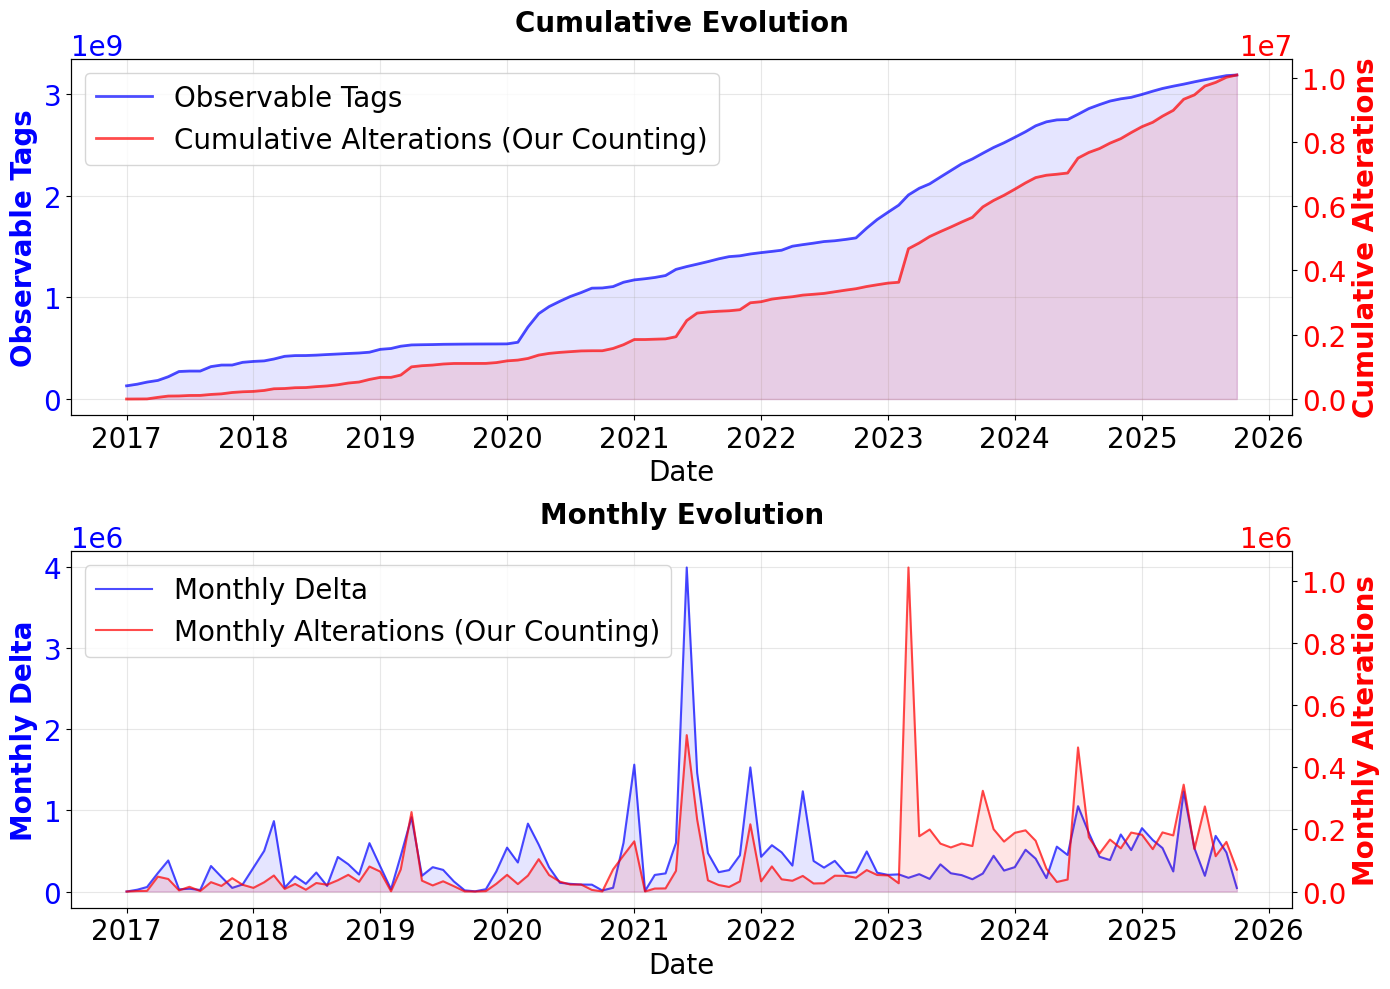


Comparison Statistics:
  Final observable tags: 3_188_191_322
  Cumulative alterations (our counting): 10_082_591
  Ratio (alterations/observable): 0.0032

Monthly averages:
  Average initial observed tags per month: 28,512,122
  Average delta per month: 400,568
  Average alterations per month (our counting): 95,119


In [23]:
# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# ============================================================
# FIGURE 1: Cumulative Evolution - Observable Stock
# ============================================================
ax1_twin = ax1.twinx()

# Plot observable stock on left y-axis
line1 = ax1.plot(plot_data_net['month_date'], plot_data_net['observable'], 
                 'b-', linewidth=2, label='Observable Tags', alpha=0.7)
ax1.fill_between(plot_data_net['month_date'], 0, plot_data_net['observable'], 
                  alpha=0.1, color='blue')

# Plot cumulative alterations (our counting) on right y-axis
cumulative_alterations_net = comparison_net['total_alterations'].cumsum()
line2 = ax1_twin.plot(comparison_net['month_date'], cumulative_alterations_net, 
                      'r-', linewidth=2, label='Cumulative Alterations (Our Counting)', alpha=0.7)
ax1_twin.fill_between(comparison_net['month_date'], 0, cumulative_alterations_net, 
                       alpha=0.1, color='red')

# Formatting
ax1.set_xlabel('Date', fontsize=FONT_SIZE)
ax1.set_ylabel('Observable Tags', fontsize=FONT_SIZE, fontweight='bold', color='blue')
ax1_twin.set_ylabel('Cumulative Alterations', fontsize=FONT_SIZE, fontweight='bold', color='red')
ax1.tick_params(axis='x', labelsize=FONT_SIZE)
ax1.tick_params(axis='y', labelcolor='blue', labelsize=FONT_SIZE)
ax1_twin.tick_params(axis='y', labelcolor='red', labelsize=FONT_SIZE)
ax1.set_title('Cumulative Evolution', fontsize=FONT_SIZE, fontweight='bold', pad=20)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator(1))

ax1.yaxis.get_offset_text().set_fontsize(FONT_SIZE)
ax1_twin.yaxis.get_offset_text().set_fontsize(FONT_SIZE)

# Add combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=FONT_SIZE)

# ============================================================
# FIGURE 2: Monthly Evolution - Delta vs Alterations
# ============================================================
ax2_twin = ax2.twinx()

# Plot monthly delta on left y-axis
line3 = ax2.plot(plot_data_net['month_date'], plot_data_net['delta'], 
                 'b-', linewidth=1.5, label='Monthly Delta', alpha=0.7)
# Use different fill for positive and negative values
ax2.fill_between(plot_data_net['month_date'], 0, plot_data_net['delta'], 
                  where=(plot_data_net['delta'] >= 0),
                  alpha=0.1, color='blue', interpolate=True)
ax2.fill_between(plot_data_net['month_date'], 0, plot_data_net['delta'], 
                  where=(plot_data_net['delta'] < 0),
                  alpha=0.1, color='orange', interpolate=True)

# Plot monthly alterations on right y-axis
line4 = ax2_twin.plot(comparison_net['month_date'], comparison_net['total_alterations'], 
                      'r-', linewidth=1.5, label='Monthly Alterations (Our Counting)', alpha=0.7)
ax2_twin.fill_between(comparison_net['month_date'], 0, comparison_net['total_alterations'], 
                       alpha=0.1, color='red')

# Formatting
ax2.set_xlabel('Date', fontsize=FONT_SIZE)
ax2.set_ylabel('Monthly Delta', fontsize=FONT_SIZE, fontweight='bold', color='blue')
ax2_twin.set_ylabel('Monthly Alterations', fontsize=FONT_SIZE, fontweight='bold', color='red')
ax2.tick_params(axis='x', labelsize=FONT_SIZE)
ax2.tick_params(axis='y', labelcolor='blue', labelsize=FONT_SIZE)
ax2_twin.tick_params(axis='y', labelcolor='red', labelsize=FONT_SIZE)
ax2.set_title('Monthly Evolution', fontsize=FONT_SIZE, fontweight='bold', pad=20)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(1))

ax2.yaxis.get_offset_text().set_fontsize(FONT_SIZE)
ax2_twin.yaxis.get_offset_text().set_fontsize(FONT_SIZE)

# Add combined legend
lines = line3 + line4
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='upper left', fontsize=FONT_SIZE)

plt.tight_layout()
plt.savefig("temporal_evolution.pdf", format='pdf')
plt.show()

print(f"\nComparison Statistics:")
print(f"  Final observable tags: {plot_data_net['observable'].iloc[-1]:_}")
print(f"  Cumulative alterations (our counting): {cumulative_alterations_net.iloc[-1]:_}")
print(f"  Ratio (alterations/observable): {(cumulative_alterations_net.iloc[-1] / plot_data_net['observable'].iloc[-1]):.4f}")
print(f"\nMonthly averages:")
print(f"  Average initial observed tags per month: {plot_data_net['initial'].mean():,.0f}")
print(f"  Average delta per month: {plot_data_net['delta'].mean():,.0f}")
print(f"  Average alterations per month (our counting): {comparison_net['total_alterations'].mean():,.0f}")

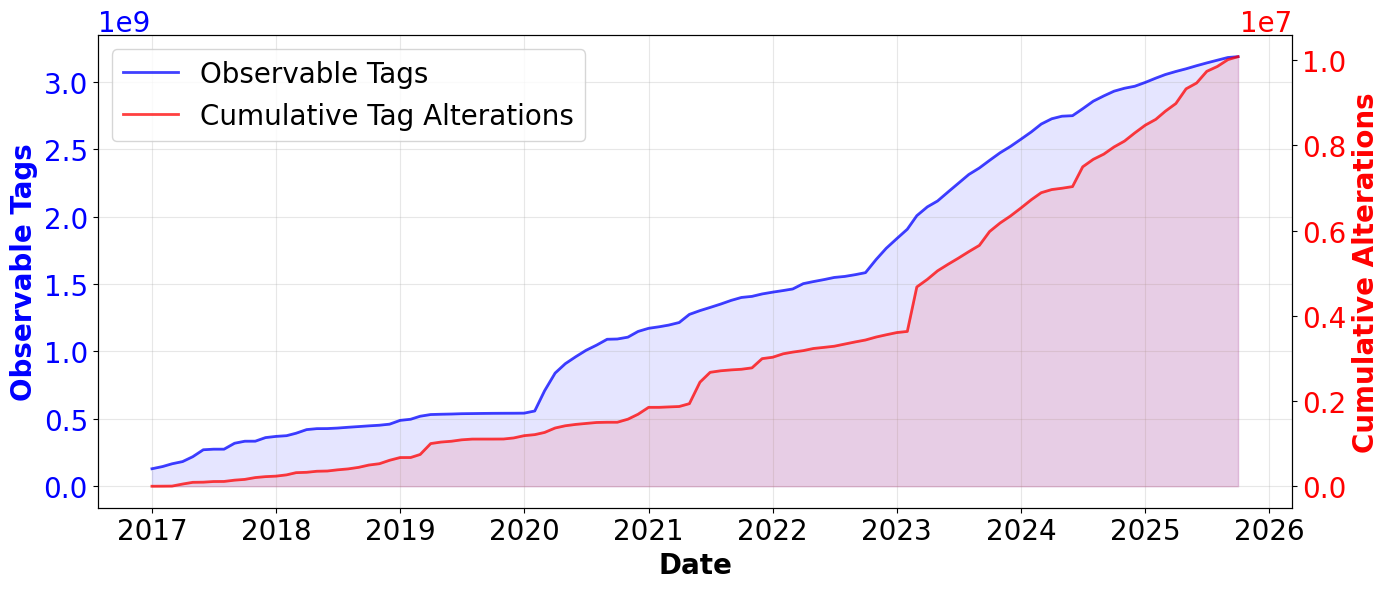

In [ ]:
# Standalone cumulative evolution plot: observable tags vs cumulative alterations
fig, ax = plt.subplots(figsize=(14, 6))
ax_twin = ax.twinx()

cum_alterations = comparison_net['total_alterations'].cumsum()

line1 = ax.plot(
    plot_data_net['month_date'],
    plot_data_net['observable'],
    'b-',
    linewidth=2,
    label='Observable Tags',
    alpha=0.75
)
ax.fill_between(
    plot_data_net['month_date'],
    0,
    plot_data_net['observable'],
    color='blue',
    alpha=0.1
)

line2 = ax_twin.plot(
    comparison_net['month_date'],
    cum_alterations,
    'r-',
    linewidth=2,
    label='Cumulative Tag Alterations',
    alpha=0.75
)
ax_twin.fill_between(
    comparison_net['month_date'],
    0,
    cum_alterations,
    color='red',
    alpha=0.1
)

ax.set_xlabel('Date', fontsize=FONT_SIZE, fontweight='bold')
ax.set_ylabel('Observable Tags', fontsize=FONT_SIZE, fontweight='bold', color='blue')
ax_twin.set_ylabel('Cumulative Alterations', fontsize=FONT_SIZE, fontweight='bold', color='red')
ax.tick_params(axis='x', labelsize=FONT_SIZE)
ax.tick_params(axis='y', labelcolor='blue', labelsize=FONT_SIZE)
ax_twin.tick_params(axis='y', labelcolor='red', labelsize=FONT_SIZE)

# Increase scientific-notation offset text size (e.g., 1e9 / 1e7).
ax.yaxis.get_offset_text().set_fontsize(FONT_SIZE)
ax_twin.yaxis.get_offset_text().set_fontsize(FONT_SIZE)

# ax.set_title('Cumulative Evolution: Observable Tags vs Alterations (2016-2025)', fontsize=FONT_SIZE, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(1))

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc='upper left', fontsize=FONT_SIZE)

plt.tight_layout()
plt.show()

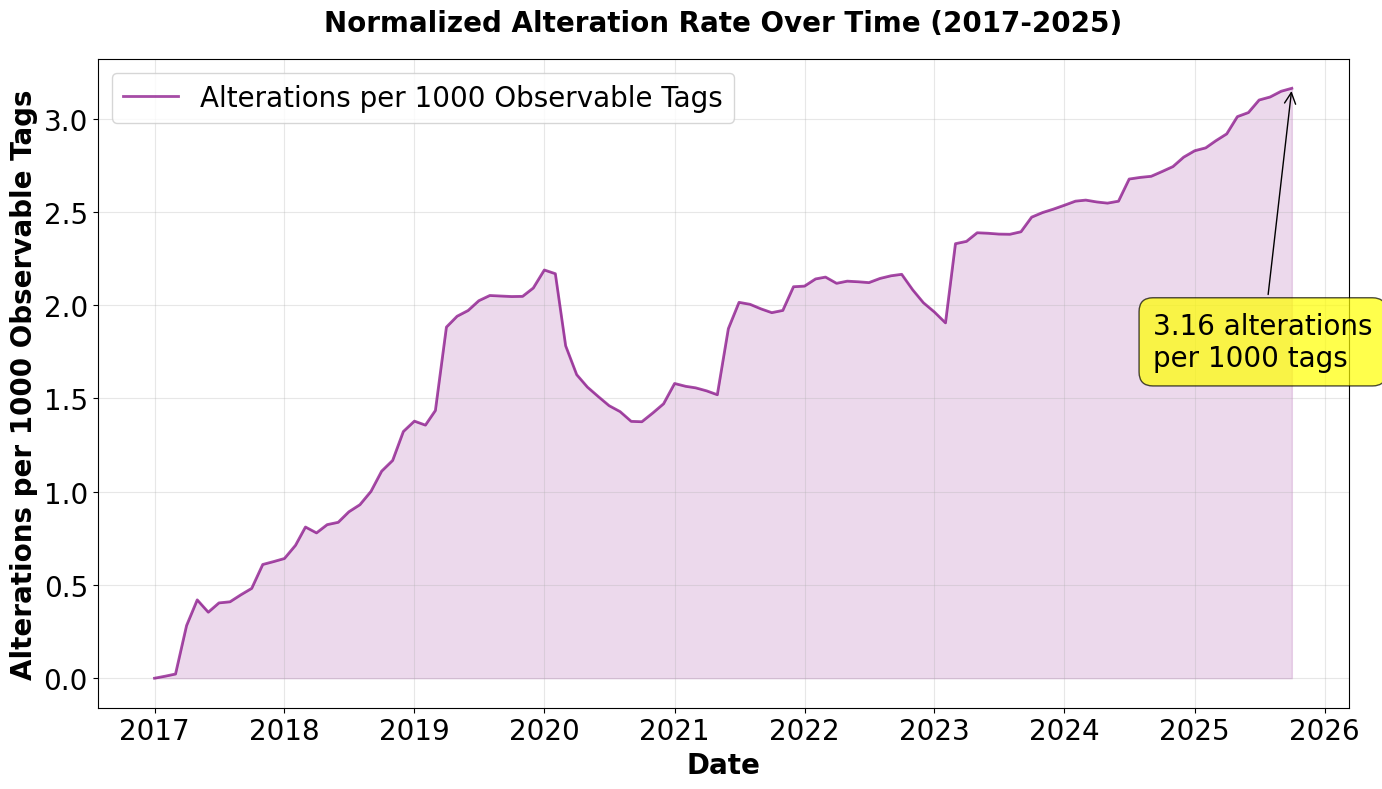


Normalized Alteration Rate Statistics:
  Initial rate (alterations per 1000 tags): 0.0000
  Final rate (alterations per 1000 tags): 3.1625
  Mean rate over period: 1.8250
  Median rate over period: 2.0139
  Maximum rate reached: 3.1625
  Maximum rate month: 2025-10


In [24]:
# Calculate normalized alteration rate per 1000 observable tags over time
comparison_net['cumulative_alterations'] = comparison_net['total_alterations'].cumsum()
comparison_net['alterations_per_1000_tags'] = (
    comparison_net['cumulative_alterations'] / comparison_net['observable'] * 1000
)

# Create plot showing normalized alteration rate over time
fig, ax = plt.subplots(figsize=(14, 8))

line = ax.plot(comparison_net['month_date'], comparison_net['alterations_per_1000_tags'], 
               'purple', linewidth=2, label='Alterations per 1000 Observable Tags', alpha=0.7)
ax.fill_between(comparison_net['month_date'], 0, comparison_net['alterations_per_1000_tags'], 
                alpha=0.15, color='purple')

# Formatting
ax.set_xlabel('Date', fontsize=FONT_SIZE, fontweight='bold')
ax.set_ylabel('Alterations per 1000 Observable Tags', fontsize=FONT_SIZE, fontweight='bold')
ax.set_title('Normalized Alteration Rate Over Time (2017-2025)', fontsize=FONT_SIZE, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.tick_params(axis='x', labelsize=FONT_SIZE)
ax.tick_params(axis='y', labelsize=FONT_SIZE)
ax.legend(loc='upper left', fontsize=FONT_SIZE)

# Add annotation for final rate
final_rate = comparison_net['alterations_per_1000_tags'].iloc[-1]
final_date = comparison_net['month_date'].iloc[-1]
ax.annotate(f'{final_rate:.2f} alterations\nper 1000 tags', 
            xy=(final_date, final_rate), 
            xytext=(-100, -200),
            textcoords='offset points',
            fontsize=FONT_SIZE,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout()
plt.savefig("normal_evolution.pdf", format='pdf')
plt.show()

print(f"\nNormalized Alteration Rate Statistics:")
print(f"  Initial rate (alterations per 1000 tags): {comparison_net['alterations_per_1000_tags'].iloc[0]:.4f}")
print(f"  Final rate (alterations per 1000 tags): {comparison_net['alterations_per_1000_tags'].iloc[-1]:.4f}")
print(f"  Mean rate over period: {comparison_net['alterations_per_1000_tags'].mean():.4f}")
print(f"  Median rate over period: {comparison_net['alterations_per_1000_tags'].median():.4f}")
print(f"  Maximum rate reached: {comparison_net['alterations_per_1000_tags'].max():.4f}")

# Find when max rate was reached
max_rate_idx = comparison_net['alterations_per_1000_tags'].idxmax()
max_rate_month = comparison_net.loc[max_rate_idx, 'month']
print(f"  Maximum rate month: {max_rate_month}")

## Repo vs Alterations

In [23]:
# Parse count_repos.log file
import re

repos_monthly_data = []

with open('../data/counts/count_repos.log', 'r') as f:
    # Skip lines until we find the header
    for line in f:
        if line.strip().startswith('Month'):
            # Skip the separator line
            next(f)
            break
    
    # Parse data lines
    for line in f:
        line = line.strip()
        if not line or line.startswith('Total origins'):
            break
        
        # Parse lines with format: "1970-01                    2               2"
        parts = line.split()
        if len(parts) >= 3:
            try:
                month = parts[0]
                new_origins = int(parts[1])
                cumulative = int(parts[2])
                
                repos_monthly_data.append({
                    'month': month,
                    'new_origins': new_origins,
                    'cumulative': cumulative
                })
            except (ValueError, IndexError):
                # Skip lines that don't match expected format
                continue

# Create DataFrame
repos_monthly_df = pd.DataFrame(repos_monthly_data)

print(f"Loaded {len(repos_monthly_df):_} months of data")
print(f"\nDate range: {repos_monthly_df['month'].iloc[0]} to {repos_monthly_df['month'].iloc[-1]}")
print(f"\nFirst few rows:")
print(repos_monthly_df.head())
print(f"\nLast few rows:")
print(repos_monthly_df.tail())

Loaded 121 months of data

Date range: 1970-01 to 2025-10

First few rows:
     month  new_origins  cumulative
0  1970-01            2           2
1  2015-07      1600216     1600218
2  2015-08      8284925     9885143
3  2015-09      1862626    11747769
4  2016-02         4188    11751957

Last few rows:
       month  new_origins  cumulative
116  2025-06      6164608   328172622
117  2025-07      5304642   333477264
118  2025-08      5638487   339115751
119  2025-09      5634401   344750152
120  2025-10      1517660   346267812


In [24]:

# Merge with monthly tags data
temporal_analysis_repo = repos_monthly_df.merge(
    alterations_by_month, 
    left_on='month', 
    right_on='alteration_month', 
    how='left'
)

temporal_analysis_repo['total_alterations'] = temporal_analysis_repo['total_alterations'].fillna(0).astype(int)
temporal_analysis_repo['annotated_alterations'] = temporal_analysis_repo['annotated_alterations'].fillna(0).astype(int)
temporal_analysis_repo['lightweight_alterations'] = temporal_analysis_repo['lightweight_alterations'].fillna(0).astype(int)

# Drop the duplicate month column
temporal_analysis_repo = temporal_analysis_repo.drop(columns=['alteration_month'], errors='ignore')

# print("=" * 70)
# print("TEMPORAL ANALYSIS (EXCLUDING NON-LEGIT)")
# print("=" * 70)
# print(f"Total months analyzed: {len(temporal_analysis_repo):_}")
# print(f"Months with alterations: {(temporal_analysis_repo['total_alterations'] > 0).sum():_}")
# print(f"\nSummary statistics (normalized per 1000 EXISTING tags):")
# print(f"  Mean alterations per 1000 tags: {temporal_analysis_repo['alterations_per_1000'].mean():.4f}")
# print(f"  Median alterations per 1000 tags: {temporal_analysis_repo['alterations_per_1000'].median():.4f}")
# print(f"  Max alterations per 1000 tags: {temporal_analysis_repo['alterations_per_1000'].max():.4f}")
# print(f"\nFinal cumulative totals:")
# print(f"  Total tags existing: {temporal_analysis_repo['cumulative_total'].iloc[-1]:_}")
# print(f"  Lightweight: {temporal_analysis_repo['cumulative_lightweight'].iloc[-1]:_}")
# print(f"  Annotated: {temporal_analysis_repo['cumulative_annotated'].iloc[-1]:_}")
# print("\n" + "=" * 70)

temporal_analysis_repo.head(10)

,month,new_origins,cumulative,total_alterations,annotated_alterations,lightweight_alterations
0,1970-01,2,2,0,0,0
1,2015-07,1600216,1600218,0,0,0
2,2015-08,8284925,9885143,0,0,0
3,2015-09,1862626,11747769,0,0,0
4,2016-02,4188,11751957,0,0,0
5,2016-03,129384,11881341,8196,2134,6062
6,2016-04,1817281,13698622,1829,638,1191
7,2016-05,2803444,16502066,6809,2751,4058
8,2016-06,1185056,17687122,10588,4300,6288
9,2016-07,10124,17697246,12867,9970,2897


In [25]:
# Prepare data for plotting: filter to 2015-2026 and add datetime column
temporal_analysis_repo['month_date'] = pd.to_datetime(temporal_analysis_repo['month'] + '-01')

plot_data_repo_alt = temporal_analysis_repo[
    (temporal_analysis_repo['month_date'] >= '2015-09-17') &
    (temporal_analysis_repo['month_date'] < '2026-01-01')
].copy()

print(f"Plotting repos vs alterations from {plot_data_repo_alt['month_date'].min().strftime('%Y-%m')} to {plot_data_repo_alt['month_date'].max().strftime('%Y-%m')}")
print(f"Total months in range: {len(plot_data_repo_alt)}")
print(f"\nSummary:")
print(f"  Total new origins in period: {plot_data_repo_alt['new_origins'].sum():_}")
print(f"  Total alterations in period: {plot_data_repo_alt['total_alterations'].sum():_}")
print(f"  Final cumulative origins: {plot_data_repo_alt['cumulative'].iloc[-1]:_}")
print(f"  Final cumulative alterations: {plot_data_repo_alt['total_alterations'].cumsum().iloc[-1]:_}")

Plotting repos vs alterations from 2016-02 to 2025-10
Total months in range: 117

Summary:
  Total new origins in period: 334_520_043
  Total alterations in period: 10_171_046
  Final cumulative origins: 346_267_812
  Final cumulative alterations: 10_171_046


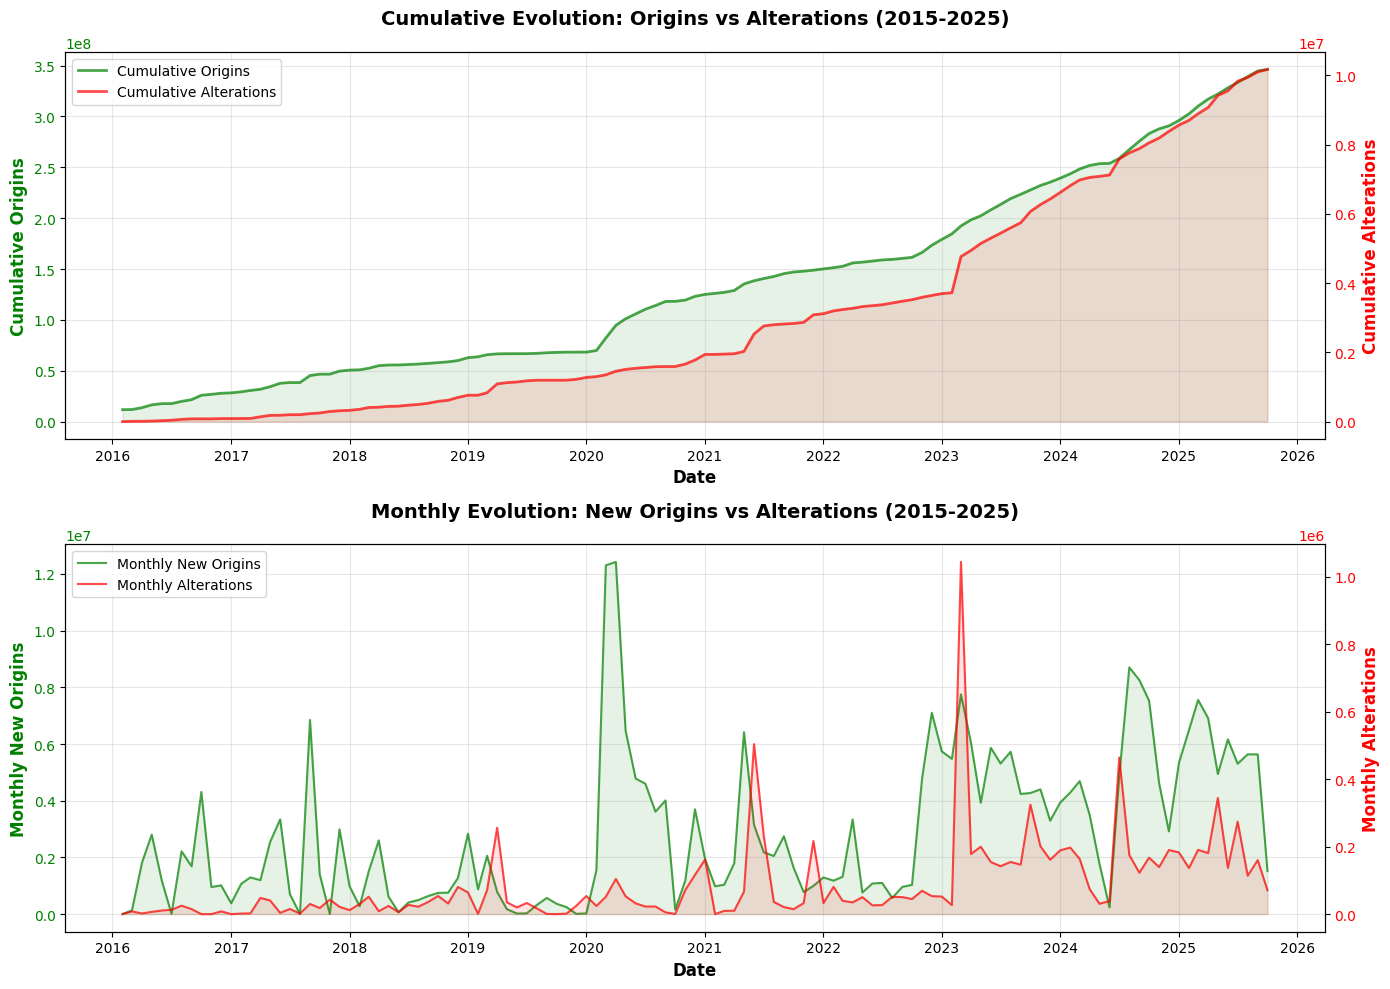


Final Statistics:
  Cumulative origins: 346_267_812
  Cumulative alterations: 10_171_046
  Alteration rate (alterations per origin): 0.0294
  Origins with alterations: 188_713
  Proportion of origins with alterations: 0.0545%


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# ============================================================
# FIGURE 1: Cumulative Evolution - Origins vs Alterations
# ============================================================
ax1_twin = ax1.twinx()

# Plot cumulative origins on left y-axis
line1 = ax1.plot(plot_data_repo_alt['month_date'], plot_data_repo_alt['cumulative'], 
                 'g-', linewidth=2, label='Cumulative Origins', alpha=0.7)
ax1.fill_between(plot_data_repo_alt['month_date'], 0, plot_data_repo_alt['cumulative'], 
                  alpha=0.1, color='green')

# Plot cumulative alterations on right y-axis
cumulative_alterations_repo = plot_data_repo_alt['total_alterations'].cumsum()
line2 = ax1_twin.plot(plot_data_repo_alt['month_date'], cumulative_alterations_repo, 
                      'r-', linewidth=2, label='Cumulative Alterations', alpha=0.7)
ax1_twin.fill_between(plot_data_repo_alt['month_date'], 0, cumulative_alterations_repo, 
                       alpha=0.1, color='red')

# Formatting
ax1.set_xlabel('Date', fontsize=FONT_SIZE, fontweight='bold')
ax1.set_ylabel('Cumulative Origins', fontsize=FONT_SIZE, fontweight='bold', color='green')
ax1_twin.set_ylabel('Cumulative Alterations', fontsize=FONT_SIZE, fontweight='bold', color='red')
ax1.tick_params(axis='x', labelsize=FONT_SIZE)
ax1.tick_params(axis='y', labelcolor='green', labelsize=FONT_SIZE)
ax1_twin.tick_params(axis='y', labelcolor='red', labelsize=FONT_SIZE)
ax1.set_title('Cumulative Evolution: Origins vs Alterations (2015-2025)', fontsize=FONT_SIZE, fontweight='bold', pad=20)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator(1))

# Add combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=FONT_SIZE)

# ============================================================
# FIGURE 2: Monthly Evolution - New Origins vs Alterations
# ============================================================
ax2_twin = ax2.twinx()

# Plot monthly new origins on left y-axis
line3 = ax2.plot(plot_data_repo_alt['month_date'], plot_data_repo_alt['new_origins'], 
                 'g-', linewidth=1.5, label='Monthly New Origins', alpha=0.7)
ax2.fill_between(plot_data_repo_alt['month_date'], 0, plot_data_repo_alt['new_origins'], 
                  alpha=0.1, color='green')

# Plot monthly alterations on right y-axis
line4 = ax2_twin.plot(plot_data_repo_alt['month_date'], plot_data_repo_alt['total_alterations'], 
                      'r-', linewidth=1.5, label='Monthly Alterations', alpha=0.7)
ax2_twin.fill_between(plot_data_repo_alt['month_date'], 0, plot_data_repo_alt['total_alterations'], 
                       alpha=0.1, color='red')

# Formatting
ax2.set_xlabel('Date', fontsize=FONT_SIZE, fontweight='bold')
ax2.set_ylabel('Monthly New Origins', fontsize=FONT_SIZE, fontweight='bold', color='green')
ax2_twin.set_ylabel('Monthly Alterations', fontsize=FONT_SIZE, fontweight='bold', color='red')
ax2.tick_params(axis='x', labelsize=FONT_SIZE)
ax2.tick_params(axis='y', labelcolor='green', labelsize=FONT_SIZE)
ax2_twin.tick_params(axis='y', labelcolor='red', labelsize=FONT_SIZE)
ax2.set_title('Monthly Evolution: New Origins vs Alterations (2015-2025)', fontsize=FONT_SIZE, fontweight='bold', pad=20)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(1))

# Add combined legend
lines = line3 + line4
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='upper left', fontsize=FONT_SIZE)

plt.tight_layout()
plt.show()

print(f"\nFinal Statistics:")
print(f"  Cumulative origins: {plot_data_repo_alt['cumulative'].iloc[-1]:_}")
print(f"  Cumulative alterations: {cumulative_alterations_repo.iloc[-1]:_}")
print(f"  Alteration rate (alterations per origin): {(cumulative_alterations_repo.iloc[-1] / plot_data_repo_alt['cumulative'].iloc[-1]):.4f}")
print(f"  Origins with alterations: {df['origin_url'].nunique():_}")
print(f"  Proportion of origins with alterations: {(df['origin_url'].nunique() / plot_data_repo_alt['cumulative'].iloc[-1] * 100):.4f}%")

In [28]:
# Compute Pearson correlation coefficient between monthly new origins and monthly alterations
from scipy import stats

# Get the two time series
monthly_new_origins = plot_data_repo_alt['new_origins'].values
monthly_alterations = plot_data_repo_alt['total_alterations'].values

# Compute Pearson correlation
pearson_r, pearson_p = stats.pearsonr(monthly_new_origins, monthly_alterations)

# Compute Spearman correlation (rank-based, more robust to outliers)
spearman_r, spearman_p = stats.spearmanr(monthly_new_origins, monthly_alterations)

print("=" * 70)
print("CORRELATION ANALYSIS: Monthly New Origins vs Monthly Alterations")
print("=" * 70)
print(f"\nPearson Correlation Coefficient:")
print(f"  r = {pearson_r:.4f}")
print(f"  p-value = {pearson_p:.4e}")
print(f"  Interpretation: {'Significant' if pearson_p < 0.05 else 'Not significant'} at α=0.05")
print(f"  Strength: ", end="")
if abs(pearson_r) < 0.3:
    print("Weak correlation")
elif abs(pearson_r) < 0.7:
    print("Moderate correlation")
else:
    print("Strong correlation")

print(f"\nSpearman Correlation Coefficient (rank-based):")
print(f"  ρ = {spearman_r:.4f}")
print(f"  p-value = {spearman_p:.4e}")
print(f"  Interpretation: {'Significant' if spearman_p < 0.05 else 'Not significant'} at α=0.05")

print(f"\nCoefficient of Determination (R²):")
print(f"  R² = {pearson_r**2:.4f}")
print(f"  Meaning: {pearson_r**2*100:.2f}% of variance in one variable is explained by the other")

print("\n" + "=" * 70)

CORRELATION ANALYSIS: Monthly New Origins vs Monthly Alterations

Pearson Correlation Coefficient:
  r = 0.4217
  p-value = 2.1936e-06
  Interpretation: Significant at α=0.05
  Strength: Moderate correlation

Spearman Correlation Coefficient (rank-based):
  ρ = 0.5723
  p-value = 1.5752e-11
  Interpretation: Significant at α=0.05

Coefficient of Determination (R²):
  R² = 0.1778
  Meaning: 17.78% of variance in one variable is explained by the other



TEMPORAL EVOLUTION OF CORRELATION SIGNIFICANCE

First statistically significant (p < 0.05):
  Date: 2023-03
  After including 86 months of data
  Pearson r = 0.2900
  p-value = 6.7511e-03

Progression around significance threshold:
  2023-01: r=0.1547, p=1.6004e-01 - Not significant
  2023-02: r=0.1483, p=1.7546e-01 - Not significant
  2023-03: r=0.2900, p=6.7511e-03 - *** FIRST SIGNIFICANT ***
  2023-04: r=0.3019, p=4.4915e-03 - ✓ Significant
  2023-05: r=0.3080, p=3.5063e-03 - ✓ Significant



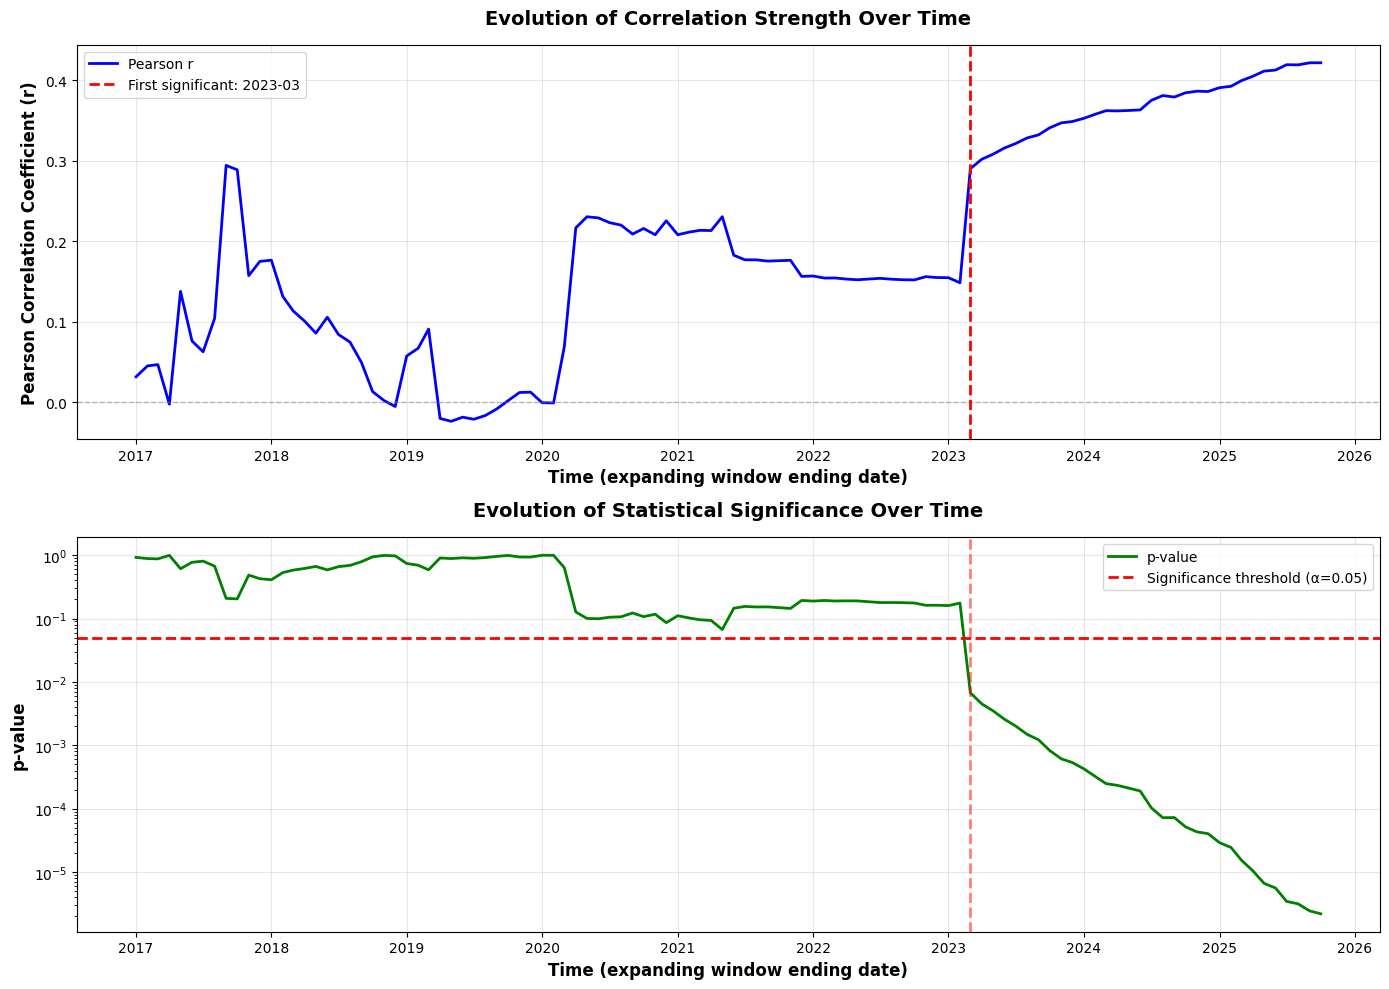

In [ ]:
# Expanding window analysis: when does the correlation become significant?
# Start with the first 12 months and expand incrementally

min_window = 12  # Minimum months needed for meaningful correlation

expanding_results = []

for i in range(min_window, len(plot_data_repo_alt) + 1):
    # Get data up to month i
    window_origins = plot_data_repo_alt['new_origins'].iloc[:i].values
    window_alterations = plot_data_repo_alt['total_alterations'].iloc[:i].values
    
    # Compute correlation for this window
    r, p = stats.pearsonr(window_origins, window_alterations)
    
    expanding_results.append({
        'months_included': i,
        'end_date': plot_data_repo_alt['month_date'].iloc[i-1],
        'end_month': plot_data_repo_alt['month'].iloc[i-1],
        'pearson_r': r,
        'p_value': p,
        'is_significant': p < 0.05
    })

expanding_df = pd.DataFrame(expanding_results)

# Find when it first becomes significant
first_significant = expanding_df[expanding_df['is_significant']].iloc[0] if expanding_df['is_significant'].any() else None

print("=" * 70)
print("TEMPORAL EVOLUTION OF CORRELATION SIGNIFICANCE")
print("=" * 70)

if first_significant is not None:
    print(f"\nFirst statistically significant (p < 0.05):")
    print(f"  Date: {first_significant['end_month']}")
    print(f"  After including {first_significant['months_included']} months of data")
    print(f"  Pearson r = {first_significant['pearson_r']:.4f}")
    print(f"  p-value = {first_significant['p_value']:.4e}")
    
    # Show progression around that point
    idx = first_significant.name
    print(f"\nProgression around significance threshold:")
    for i in range(max(0, idx-2), min(len(expanding_df), idx+3)):
        row = expanding_df.iloc[i]
        sig_marker = "*** FIRST SIGNIFICANT ***" if i == idx else ("✓ Significant" if row['is_significant'] else "Not significant")
        print(f"  {row['end_month']}: r={row['pearson_r']:6.4f}, p={row['p_value']:.4e} - {sig_marker}")
else:
    print("\nCorrelation never reached statistical significance in the time period analyzed.")

print("\n" + "=" * 70)

# Plot the evolution
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Evolution of correlation coefficient
ax1.plot(expanding_df['end_date'], expanding_df['pearson_r'], 'b-', linewidth=2, label='Pearson r')
ax1.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
if first_significant is not None:
    ax1.axvline(x=first_significant['end_date'], color='red', linestyle='--', linewidth=2, 
                label=f'First significant: {first_significant["end_month"]}')
ax1.set_xlabel('Time (expanding window ending date)', fontsize=FONT_SIZE, fontweight='bold')
ax1.set_ylabel('Pearson Correlation Coefficient (r)', fontsize=FONT_SIZE, fontweight='bold')
ax1.set_title('Evolution of Correlation Strength Over Time', fontsize=FONT_SIZE, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', labelsize=FONT_SIZE)
ax1.tick_params(axis='y', labelsize=FONT_SIZE)
ax1.legend(loc='best', fontsize=FONT_SIZE)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Plot 2: Evolution of p-value
ax2.plot(expanding_df['end_date'], expanding_df['p_value'], 'g-', linewidth=2, label='p-value')
ax2.axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='Significance threshold (α=0.05)')
if first_significant is not None:
    ax2.axvline(x=first_significant['end_date'], color='red', linestyle='--', linewidth=2, alpha=0.5)
ax2.set_xlabel('Time (expanding window ending date)', fontsize=FONT_SIZE, fontweight='bold')
ax2.set_ylabel('p-value', fontsize=FONT_SIZE, fontweight='bold')
ax2.set_title('Evolution of Statistical Significance Over Time', fontsize=FONT_SIZE, fontweight='bold', pad=15)
ax2.set_yscale('log')  # Log scale to better see p-value changes
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', labelsize=FONT_SIZE)
ax2.tick_params(axis='y', labelsize=FONT_SIZE)
ax2.legend(loc='best', fontsize=FONT_SIZE)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

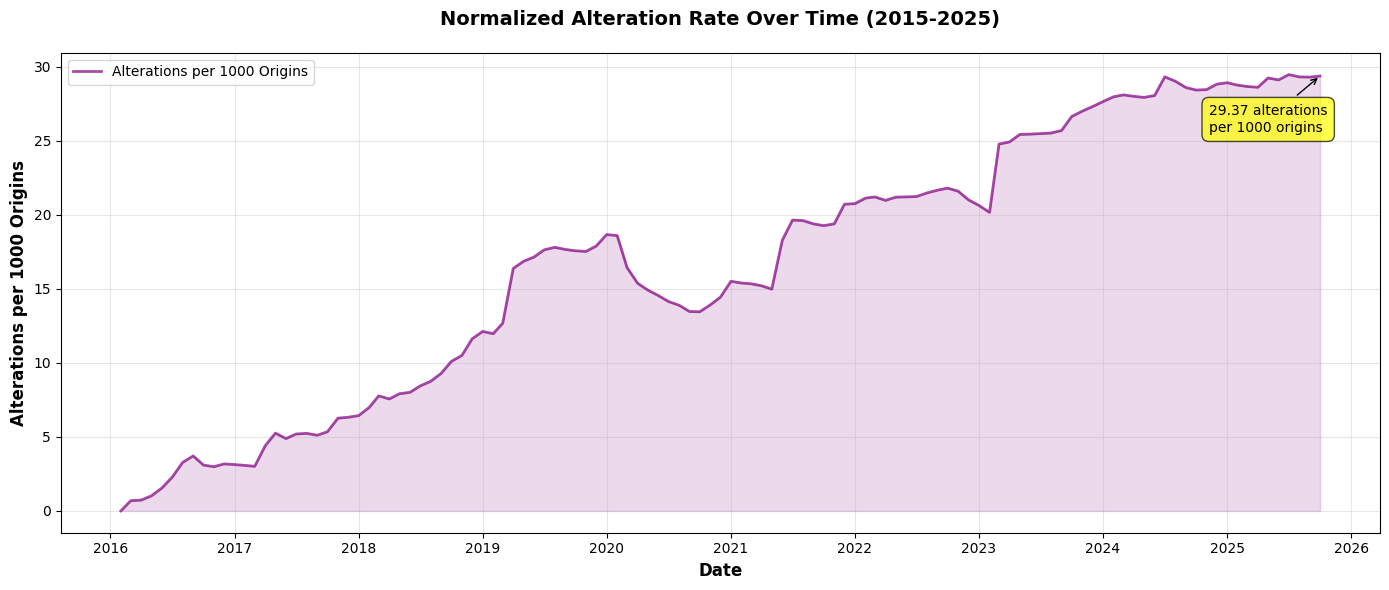


Normalized Alteration Rate Statistics:
  Initial rate (alteration per 1000 origins): 0.0000
  Final rate (alterations per 1000 origins): 29.3734
  Mean rate over period: 16.7193
  Median rate over period: 17.6315
  Maximum rate reached: 29.4671
  Maximum rate month: 2025-07


In [ ]:
# Calculate alterations per 1000 origins over time
plot_data_repo_alt['cumulative_alterations'] = plot_data_repo_alt['total_alterations'].cumsum()
plot_data_repo_alt['alterations_per_1000_origins'] = (
    plot_data_repo_alt['cumulative_alterations'] / plot_data_repo_alt['cumulative'] * 1000
)

# Create plot showing normalized alteration rate over time
fig, ax = plt.subplots(figsize=(14, 6))

line = ax.plot(plot_data_repo_alt['month_date'], plot_data_repo_alt['alterations_per_1000_origins'], 
               'purple', linewidth=2, label='Alterations per 1000 Origins', alpha=0.7)
ax.fill_between(plot_data_repo_alt['month_date'], 0, plot_data_repo_alt['alterations_per_1000_origins'], 
                alpha=0.15, color='purple')

# Formatting
ax.set_xlabel('Date', fontsize=FONT_SIZE, fontweight='bold')
ax.set_ylabel('Alterations per 1000 Origins', fontsize=FONT_SIZE, fontweight='bold')
ax.set_title('Normalized Alteration Rate Over Time (2015-2025)', fontsize=FONT_SIZE, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.tick_params(axis='x', labelsize=FONT_SIZE)
ax.tick_params(axis='y', labelsize=FONT_SIZE)
ax.legend(loc='upper left', fontsize=FONT_SIZE)

# Add annotation for final rate
final_rate = plot_data_repo_alt['alterations_per_1000_origins'].iloc[-1]
final_date = plot_data_repo_alt['month_date'].iloc[-1]
ax.annotate(f'{final_rate:.2f} alterations\nper 1000 origins', 
            xy=(final_date, final_rate), 
            xytext=(-80, -40),
            textcoords='offset points',
            fontsize=FONT_SIZE,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout()
plt.show()

print(f"\nNormalized Alteration Rate Statistics:")
print(f"  Initial rate (alteration per 1000 origins): {plot_data_repo_alt['alterations_per_1000_origins'].iloc[0]:.4f}")
print(f"  Final rate (alterations per 1000 origins): {plot_data_repo_alt['alterations_per_1000_origins'].iloc[-1]:.4f}")
print(f"  Mean rate over period: {plot_data_repo_alt['alterations_per_1000_origins'].mean():.4f}")
print(f"  Median rate over period: {plot_data_repo_alt['alterations_per_1000_origins'].median():.4f}")
print(f"  Maximum rate reached: {plot_data_repo_alt['alterations_per_1000_origins'].max():.4f}")

# Find when max rate was reached
max_rate_idx = plot_data_repo_alt['alterations_per_1000_origins'].idxmax()
max_rate_month = plot_data_repo_alt.loc[max_rate_idx, 'month']
print(f"  Maximum rate month: {max_rate_month}")

# Taxonomy

In [ ]:
conn = sqlite3.connect('../data/tags_alterations_full_2025-10_v2.db')
diffs = pd.read_sql_query("SELECT * FROM tag_diffs", conn)
# files = pd.read_sql_query("SELECT * FROM tag_file_diffs", conn)

# print(f"Loaded {len(files):_} rows from database")
print(f"Loaded {len(diffs):_} rows from database")

Loaded 626_008 rows from database


In [7]:
diffs[diffs['rel_message_differs'].notna()].head(5)

,origin_url,tag_name,tag_type,old_snapshot,altering_snapshot,old_snap_timestamp,old_release_swhid,new_release_swhid,old_revision_swhid,new_revision_swhid,old_directory_swhid,new_directory_swhid,rel_message_differs,rel_author_differs,rel_author_timestamp_differs,rev_message_differs,rev_author_differs,rev_committer_differs,rev_author_timestamp_differs,rev_committer_timestamp_differs,dir_added,dir_deleted,dir_modified,dir_renamed
17,https://github.com/netsecsp/aftpx,refs/tags/1.2,annotated,swh:1:snp:904b1019f5dd78512b7243dbbda36ec5a84d0b2a,swh:1:snp:3a52110e1afc36346e5527be9ead961263dde088,1652829509,swh:1:rel:a737d81fe8a3478a062cd66e7f91a48aee0700f6,swh:1:rel:43efe98c75aa10c233f80dc782071a2d0321defe,swh:1:rev:3d97b7f47634df91fcaa6c617613f2f0f171d384,swh:1:rev:7b76beb54d8d80161cd06a346700b6906313a632,swh:1:dir:d9cd4b4fcf23f4429c071597f43276204dc7cdb7,swh:1:dir:72201067c1d5cbcf97f868d6003be04f2921fba3,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,2.0,2.0,81.0,0.0
18,https://github.com/exploratory-io/exploratory_func,refs/tags/v9.0.4,annotated,swh:1:snp:6e29672775e540b94eb7eceb90ae429407d52149,swh:1:snp:eedde52d07f0ec818a36fb712329dd4473cdcdd6,1709319338,swh:1:rel:3dc0e2da0b2ff65b3b8cfebff9d8d590bdc28366,swh:1:rel:aa9d6b69577021b1aeb3802e2ebd0bff6beb2380,swh:1:rev:6f16e42648dd6b2aa20adf7bd21ba05809beb521,swh:1:rev:67f5e3eb3c11c3ec94f9ca7b107beec715959777,swh:1:dir:20090e6f09b35a1c653e8cc65af9ccc2c42d2895,swh:1:dir:8db796a63b61f2cc1a52a53b3bfb4e7356467947,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
23,https://github.com/ThinkingDataAnalytics/ios-sdk,refs/tags/v2.8.2,annotated,swh:1:snp:4631c43cdc09ed21389ea06cd43ad988ab5041b6,swh:1:snp:faa054d9b46d6609ec763f84af3b37141f5c16a5,1666003050,swh:1:rel:187c2101fc1e5b1c4b04489a383c820b9588933e,swh:1:rel:cb29d1ae31ddce2e021a5d4b06b202a9d620c16a,swh:1:rev:511eb592045ff064c0b0fac4b4c09fa42c4e0551,swh:1:rev:7b16607ec0bbd65e65d3f4b625b529fb77cfc281,swh:1:dir:effb81e567c548e781a2af75e83e6d7955e67c2c,swh:1:dir:e9a763df018b77a35c813e0d43ff62f45e5ba862,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,23.0,0.0,207.0,0.0
24,https://github.com/ThinkingDataAnalytics/ios-sdk,refs/tags/v2.7.4,annotated,swh:1:snp:26bfb178d3f536a32fdc73a580f2d19536546609,swh:1:snp:c1bfc417776f6953aff26ef2600d63958cce1940,1643061100,swh:1:rel:aef92a8b2b184e6347065b045527de71519ae4a6,swh:1:rel:cbf0ab0a978e3cee8060d01129a42e079e618117,swh:1:rev:d543b7d0c39818bf540fbbc866642c0a7d5eefb4,swh:1:rev:0ebadd8441f7c13677db75ee03fcc3320b143b00,swh:1:dir:2b217826ccc3dfa6fea64e4918c24959da8ea6d5,swh:1:dir:e864a8962ff5290a191534da3506be46fb72fb16,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,2.0,3.0,0.0
25,https://github.com/ThinkingDataAnalytics/ios-sdk,refs/tags/v2.6.5,annotated,swh:1:snp:222e793009529ccda47ee5a06f6fda7e21019b73,swh:1:snp:c1bfc417776f6953aff26ef2600d63958cce1940,1624392023,swh:1:rel:fd2f90d38ecb1de4c84af0f582d2457086715d6e,swh:1:rel:7719a776db33e95b3f7f0349ad704805a208dc06,swh:1:rev:8c7b7408af11fef73875e72146ce969f9fb7a75c,swh:1:rev:eb447ab7a232039600583afd074339ec345e50e6,swh:1:dir:e208f8a221391409745e506a210545b8b1532d68,swh:1:dir:7ddd936b243a754a807f7a89a689d9680a5aa6ee,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0


In [8]:
deletion_creation_similar_lightweight = diffs[((diffs['tag_type']=='lightweight') & (diffs['old_revision_swhid']==diffs['new_revision_swhid']) & (diffs['new_release_swhid'].isna()))]
print(f'Amount of lightweight tag alteration deletion --> recreation exact same: {len(deletion_creation_similar_lightweight):_}')
deletion_creation_similar_annotated = diffs[((diffs['tag_type']=='annotated') & (diffs['old_release_swhid']==diffs['new_release_swhid']))]
print(f'Amount of annotated tag alteration deletion --> recreation exact same: {len(deletion_creation_similar_annotated):_}')

Amount of lightweight tag alteration deletion --> recreation exact same: 160
Amount of annotated tag alteration deletion --> recreation exact same: 0


In [9]:
releases_diffs = diffs[(diffs['old_release_swhid'] != diffs['new_release_swhid']) & (diffs['old_revision_swhid'] == diffs['new_revision_swhid'])]
print(f'Amount of tag alteration not modifying Revision metadata nor content: {len(releases_diffs):_} --> {(len(releases_diffs)/len(diffs))*100:.2f}%')


# Tags that transitioned between annotated (has release SWHID) and lightweight (no release SWHID)
type_transitions = diffs[
    (diffs['old_release_swhid'].isna() != diffs['new_release_swhid'].isna())
]
print(f'Annotated <-> lightweight transitions: {len(type_transitions):_} --> {(len(type_transitions)/len(diffs))*100:.2f}%')

# True release metadata changes: both SWHIDs present, release changed, revision unchanged
releases_diffs_not_transition = diffs[
    (diffs['old_release_swhid'].notna()) &
    (diffs['new_release_swhid'].notna()) &
    (diffs['old_release_swhid'] != diffs['new_release_swhid']) &
    (diffs['old_revision_swhid'] == diffs['new_revision_swhid'])  
]
print(f'Amount of tag alteration modifying only the Release metadata: {len(releases_diffs_not_transition):_} --> {(len(releases_diffs_not_transition)/len(diffs))*100:.2f}%')

Amount of tag alteration not modifying Revision metadata nor content: 10_439 --> 1.67%
Annotated <-> lightweight transitions: 49_302 --> 7.88%
Amount of tag alteration modifying only the Release metadata: 0 --> 0.00%


In [10]:
lightweight_to_annotated = releases_diffs[(releases_diffs['old_release_swhid'].isna()) & (releases_diffs['new_release_swhid'].notna())]
annotated_to_lightweight = releases_diffs[(releases_diffs['new_release_swhid'].isna()) & (releases_diffs['old_release_swhid'].notna())]
print(f"Lightweight --> Annotated: {len(lightweight_to_annotated):_}")
print(f"Annotated --> Lightweight: {len(annotated_to_lightweight):_}")

Lightweight --> Annotated: 7_555
Annotated --> Lightweight: 2_724


In [11]:
revision_diffs = diffs[(diffs['old_revision_swhid'] != diffs['new_revision_swhid']) & (diffs['old_directory_swhid'] == diffs['new_directory_swhid'])]
print(f'Amount of tag alteration modifying only the Revision metadata: {len(revision_diffs):_} --> {(len(revision_diffs)/len(diffs))*100:.2f}%')

Amount of tag alteration modifying only the Revision metadata: 188_974 --> 30.19%


In [12]:
directory_diffs = diffs[(diffs['old_directory_swhid'] != diffs['new_directory_swhid'])]
print(f'Amount of tag alteration modifying content: {len(directory_diffs):_} --> {(len(directory_diffs)/len(diffs))*100:.2f}%')

Amount of tag alteration modifying content: 426_595 --> 68.15%


In [13]:
releases_diffs[(releases_diffs['old_release_swhid'].notna()) & (releases_diffs['new_release_swhid'].notna())]

,origin_url,tag_name,tag_type,old_snapshot,altering_snapshot,old_snap_timestamp,old_release_swhid,new_release_swhid,old_revision_swhid,new_revision_swhid,old_directory_swhid,new_directory_swhid,rel_message_differs,rel_author_differs,rel_author_timestamp_differs,rev_message_differs,rev_author_differs,rev_committer_differs,rev_author_timestamp_differs,rev_committer_timestamp_differs,dir_added,dir_deleted,dir_modified,dir_renamed


In [14]:

total_rows = len(diffs)

# ============================================================
# RELEASE DIFFS: alterations modifying only Release metadata
# ============================================================
rel_cols = ['rel_message_differs', 'rel_author_differs', 'rel_author_timestamp_differs']
rel_count = len(releases_diffs)

print("=" * 60)
print("RELEASE DIFF STATISTICS")
print(f"(old_release_swhid != new_release_swhid AND old_revision_swhid == new_revision_swhid)")
print("=" * 60)
print(f"Count: {rel_count:_} ({rel_count/total_rows*100:.2f}% of all diffs)\n")

for col in rel_cols:
    count = ((releases_diffs[col].notna()) & (releases_diffs[col] > 0)).sum()
    pct = (count / rel_count * 100) if rel_count > 0 else 0
    print(f"  {col}: {count:_} ({pct:.2f}%)")

# ============================================================
# REVISION DIFFS: alterations modifying only Revision metadata
# ============================================================
rev_cols = ['rev_message_differs', 'rev_author_differs', 'rev_committer_differs',
            'rev_author_timestamp_differs', 'rev_committer_timestamp_differs']
rev_count = len(revision_diffs)

print("\n" + "=" * 60)
print("REVISION DIFF STATISTICS")
print(f"(old_revision_swhid != new_revision_swhid AND old_directory_swhid == new_directory_swhid)")
print("=" * 60)
print(f"Count: {rev_count:_} ({rev_count/total_rows*100:.2f}% of all diffs)\n")

for col in rev_cols:
    count = ((revision_diffs[col].notna()) & (revision_diffs[col] > 0)).sum()
    pct = (count / rev_count * 100) if rev_count > 0 else 0
    print(f"  {col}: {count:_} ({pct:.2f}%)")

# ============================================================
# DIRECTORY DIFFS: alterations modifying content
# ============================================================
dir_cols = ['dir_added', 'dir_deleted', 'dir_modified', 'dir_renamed']
dir_count = len(directory_diffs)

print("\n" + "=" * 60)
print("DIRECTORY DIFF STATISTICS")
print(f"(old_directory_swhid != new_directory_swhid)")
print("=" * 60)
print(f"Count: {dir_count:_} ({dir_count/total_rows*100:.2f}% of all diffs)\n")

for col in dir_cols:
    col_data = directory_diffs[col]
    count = (col_data > 0).sum()
    pct = (count / dir_count * 100) if dir_count > 0 else 0
    q1   = col_data.quantile(0.25)
    q2   = col_data.quantile(0.50)
    q3   = col_data.quantile(0.75)
    p90  = col_data.quantile(0.90)
    p95  = col_data.quantile(0.95)
    p99  = col_data.quantile(0.99)
    mean_val  = col_data.mean()
    total_val = col_data.sum()
    print(f"  {col}:")
    print(f"    Rows with ≥1: {count:_} ({pct:.2f}%)")
    print(f"    Mean: {mean_val:.2f}  |  Total: {total_val:_}")
    print(f"    Q1: {q1:.0f}  |  Q2 (median): {q2:.0f}  |  Q3: {q3:.0f}")
    print(f"    P90: {p90:.0f}  |  P95: {p95:.0f}  |  P99: {p99:.0f}")

print("\n" + "=" * 60)


RELEASE DIFF STATISTICS
(old_release_swhid != new_release_swhid AND old_revision_swhid == new_revision_swhid)
Count: 10_439 (1.67% of all diffs)

  rel_message_differs: 0 (0.00%)
  rel_author_differs: 0 (0.00%)
  rel_author_timestamp_differs: 0 (0.00%)

REVISION DIFF STATISTICS
(old_revision_swhid != new_revision_swhid AND old_directory_swhid == new_directory_swhid)
Count: 188_974 (30.19% of all diffs)

  rev_message_differs: 37_009 (19.58%)
  rev_author_differs: 51_820 (27.42%)
  rev_committer_differs: 54_322 (28.75%)
  rev_author_timestamp_differs: 21_123 (11.18%)
  rev_committer_timestamp_differs: 24_746 (13.09%)

DIRECTORY DIFF STATISTICS
(old_directory_swhid != new_directory_swhid)
Count: 426_595 (68.15% of all diffs)

  dir_added:
    Rows with ≥1: 219_117 (51.36%)
    Mean: 432.58  |  Total: 184_537_915.0
    Q1: 0  |  Q2 (median): 1  |  Q3: 14
    P90: 216  |  P95: 1017  |  P99: 6207
  dir_deleted:
    Rows with ≥1: 217_789 (51.05%)
    Mean: 137.16  |  Total: 58_511_744.0
    

In [18]:
revision_diffs[(revision_diffs['rev_committer_timestamp_differs'] == 0) & ((revision_diffs['rev_message_differs'] != 0) | (revision_diffs['rev_author_differs'] != 0) | (revision_diffs['rev_committer_differs'] != 0) | (revision_diffs['rev_author_timestamp_differs'] != 0))]

,origin_url,tag_name,tag_type,old_snapshot,altering_snapshot,old_snap_timestamp,old_release_swhid,new_release_swhid,old_revision_swhid,new_revision_swhid,old_directory_swhid,new_directory_swhid,rel_message_differs,rel_author_differs,rel_author_timestamp_differs,rev_message_differs,rev_author_differs,rev_committer_differs,rev_author_timestamp_differs,rev_committer_timestamp_differs,dir_added,dir_deleted,dir_modified,dir_renamed
126,https://gitlab.com/project-open/workflow.git,refs/tags/v3-2-3-0-0,lightweight,swh:1:snp:c7e09bae62db38ec458a104a04a93224077d8421,swh:1:snp:e2bb5003f69cab4e09ebac98e8e545573e354ef7,1555985301,NaN,NaN,swh:1:rev:dfee281d5f340c5738d0816d80c1c94332286c2d,swh:1:rev:d00d825aa15bec2bd78b4c1027dc10c08c6b55ba,swh:1:dir:ddcd4f61080ff31e3a17b398519a545a4b27faac,swh:1:dir:ddcd4f61080ff31e3a17b398519a545a4b27faac,NaN,NaN,NaN,0.0,1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN
128,https://gitlab.com/project-open/workflow.git,refs/tags/v3-3-1-1-1,lightweight,swh:1:snp:c7e09bae62db38ec458a104a04a93224077d8421,swh:1:snp:e2bb5003f69cab4e09ebac98e8e545573e354ef7,1555985301,NaN,NaN,swh:1:rev:edafd4cc19b5753f4f09a2720b2de604fcfcee74,swh:1:rev:3e70fc66ce971ecb4a7893570fa7227a67ec7928,swh:1:dir:edc9437fa9b55acef9e1be79773d6cbfecd2d2f7,swh:1:dir:edc9437fa9b55acef9e1be79773d6cbfecd2d2f7,NaN,NaN,NaN,0.0,1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN
132,https://gitlab.com/project-open/workflow.git,refs/tags/v3-2-7-0-0,lightweight,swh:1:snp:c7e09bae62db38ec458a104a04a93224077d8421,swh:1:snp:e2bb5003f69cab4e09ebac98e8e545573e354ef7,1555985301,NaN,NaN,swh:1:rev:3f27085b069ab4e062579b048206db39334da035,swh:1:rev:18bd1798fc102f99d420ab92dcef1b1a41ace6ca,swh:1:dir:da45949c8770e44817446ab83ebcb8935dbc0a05,swh:1:dir:da45949c8770e44817446ab83ebcb8935dbc0a05,NaN,NaN,NaN,0.0,1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN
134,https://gitlab.com/project-open/workflow.git,refs/tags/v3-2-9-0-0,lightweight,swh:1:snp:c7e09bae62db38ec458a104a04a93224077d8421,swh:1:snp:e2bb5003f69cab4e09ebac98e8e545573e354ef7,1555985301,NaN,NaN,swh:1:rev:3f27085b069ab4e062579b048206db39334da035,swh:1:rev:18bd1798fc102f99d420ab92dcef1b1a41ace6ca,swh:1:dir:da45949c8770e44817446ab83ebcb8935dbc0a05,swh:1:dir:da45949c8770e44817446ab83ebcb8935dbc0a05,NaN,NaN,NaN,0.0,1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN
138,https://gitlab.com/project-open/workflow.git,refs/tags/start,lightweight,swh:1:snp:c7e09bae62db38ec458a104a04a93224077d8421,swh:1:snp:e2bb5003f69cab4e09ebac98e8e545573e354ef7,1555985301,NaN,NaN,swh:1:rev:dfee281d5f340c5738d0816d80c1c94332286c2d,swh:1:rev:d00d825aa15bec2bd78b4c1027dc10c08c6b55ba,swh:1:dir:ddcd4f61080ff31e3a17b398519a545a4b27faac,swh:1:dir:ddcd4f61080ff31e3a17b398519a545a4b27faac,NaN,NaN,NaN,0.0,1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
624919,https://gitlab.com/7lpdwcaw/GrowTracker-Android.git,refs/tags/v2.4-alpha1,lightweight,swh:1:snp:c212e01a6e742a2be4054d04252ff732c27627cf,swh:1:snp:dc2e639de6f13bb8944307c660abdee9c4cddf62,1555981353,NaN,NaN,swh:1:rev:04c459a6631be337ff72aecf3c8bd2431771670b,swh:1:rev:38694a3605dd030ff2bc4fc6c61e91b54486a460,swh:1:dir:6464fc8431d7e191734dcafc28c4d492711778e6,swh:1:dir:6464fc8431d7e191734dcafc28c4d492711778e6,NaN,NaN,NaN,0.0,1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN
625758,https://github.com/jeffreykegler/c-marpaESLIF,refs/tags/1.0.7,lightweight,swh:1:snp:cb520fed17c6a357d3a7a12056f33a93d2d7dd36,swh:1:snp:904d3bc546d1e1679c2e9277eec6bed071ce682e,1522520267,NaN,NaN,swh:1:rev:ed75baf7623e647765a7c1bcb02f7793c227b75a,swh:1:rev:014ef3aed78691711c898f50c2cf58c338344808,swh:1:dir:a9cac82701e882a541c40930584ee24241442a67,swh:1:dir:a9cac82701e882a541c40930584ee24241442a67,NaN,NaN,NaN,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
625774,https://github.com/jeffreykegler/c-marpaESLIF,refs/tags/1.0.19,lightweight,swh:1:snp:cb520fed17c6a357d3a7a12056f33a93d2d7dd36,swh:1:snp:904d3bc546d1e1679c2e9277eec6bed071ce682e,1522520267,NaN,NaN,swh:1:rev:6864236a677e17507276d0a80b83c8dab819c9aa,swh:1:rev:c59c2888c6637f7

In [20]:
check = revision_diffs[(revision_diffs['rev_committer_timestamp_differs'] == 0) & (revision_diffs['rev_message_differs'] == 0) & (revision_diffs['rev_author_differs'] == 0) & (revision_diffs['rev_committer_differs'] == 0) & (revision_diffs['rev_author_timestamp_differs'] == 0)]
check.sample(10)

,origin_url,tag_name,tag_type,old_snapshot,altering_snapshot,old_snap_timestamp,old_release_swhid,new_release_swhid,old_revision_swhid,new_revision_swhid,old_directory_swhid,new_directory_swhid,rel_message_differs,rel_author_differs,rel_author_timestamp_differs,rev_message_differs,rev_author_differs,rev_committer_differs,rev_author_timestamp_differs,rev_committer_timestamp_differs,dir_added,dir_deleted,dir_modified,dir_renamed
226044,https://github.com/ggear/asystem,refs/tags/10.100.1980,annotated,swh:1:snp:0b799fa8aca434da21ae2d7b5e70586719e1dd1e,swh:1:snp:a133ae2c98a681d3a37fe9b6d5c18c86eed716a7,1625020690,swh:1:rel:2f296278b65948dc15f9e2d7c201c24ff394b9d8,swh:1:rel:5b2858149464b33dce70b581607d42bc12143ce4,swh:1:rev:6e7e4f20b3f3a99a252cb3f0e4f17b0eda1fd37d,swh:1:rev:eed83dc1fdb581fbe4accb364da343527b72da40,swh:1:dir:bafeea103c67a6331d5e5e30ad18cf7322082627,swh:1:dir:bafeea103c67a6331d5e5e30ad18cf7322082627,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
206846,https://gitlab.com/quickcorp/QCObjects.git,refs/tags/v2.2.611,annotated,swh:1:snp:b9b6a607d78c834aa803cc2bb5a98a02633e51d0,swh:1:snp:f84b0cbbff1b673407c74d77e03be3575feb6b32,1640347582,swh:1:rel:7d7fcb6ae04ac1d06f19aa72a1180f5d0603c244,swh:1:rel:93dcc356473691fce1892e86d532f403dd880ff7,swh:1:rev:803b998d52dc3cc4abca05626c8f1ce2b7073d79,swh:1:rev:522f12c73eb254b7d7836d8d1a031303832ad73d,swh:1:dir:2435c23a7e44c3950795d1945033242ea65dcd58,swh:1:dir:2435c23a7e44c3950795d1945033242ea65dcd58,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
317848,https://github.com/horatio-sans-serif/open-wc,refs/tags/@open-wc/testing@0.9.0,annotated,swh:1:snp:4b27bbbea9b473deafb1664db2f09627be34a506,swh:1:snp:175f47ae52311920acb2cc9aea50dfa44d53153e,1749250899,swh:1:rel:4e8875c0caf406ba71031192f70bea76b0dd79c2,swh:1:rel:771c30497633447b21daf960f31816204ceb27e2,swh:1:rev:54c367d31859c77799b82b197749c6ebcd00cb1a,swh:1:rev:4b72a7f4b739645d4c033b2881605bd9f185dc55,swh:1:dir:eb8f9b8f9dee9f8cd93bd644b685c237301b60cd,swh:1:dir:eb8f9b8f9dee9f8cd93bd644b685c237301b60cd,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
423103,https://github.com/Crowndev/crowncoin,refs/tags/v0.6.0rc3,annotated,swh:1:snp:8c27f2075f3275f13f02bc80f5c984b94ecb5ec0,swh:1:snp:8c798a1fc66c8ac1661b766f48891d90e4eba4e8,1477432244,swh:1:rel:5b896be74477ac26b238a773e5991e9c2e11b759,swh:1:rel:f6527302b61118a7212a72e86200b946ad1d1e9d,swh:1:rev:e318b99d99a44396856e702520182522f9a4b9c5,swh:1:rev:27ebf89dc135dd46d9ce5f213bbd120b1fd256fd,swh:1:dir:223aed0ccd2e5d9494a5f2c2ad469e50eab2fc61,swh:1:dir:223aed0ccd2e5d9494a5f2c2ad469e50eab2fc61,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
559003,https://github.com/Fishwaldo/open-zwave,refs/tags/v1.2,lightweight,swh:1:snp:3c493d3298f7191503903cc6e187a44e48a14118,swh:1:snp:04839337cc2694bc338ce04d8b74be1bf012b845,1483145919,NaN,NaN,swh:1:rev:cf2b458af9f2414a2cf0da156de40823288be96d,swh:1:rev:414c0d7a3efd17c05904a09935142464229b659b,swh:1:dir:7d91cbee74088018dd28775a2afa3ead9bfecf2e,swh:1:dir:7d91cbee74088018dd28775a2afa3ead9bfecf2e,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
490109,https://github.com/full-build/full-build,refs/tags/2.0.448,lightweight,swh:1:snp:044c881fb14bc6888928ca771a218556883cf58a,swh:1:snp:7675789d0076d099dd82e201d250dd7502c1b258,1482875179,NaN,NaN,swh:1:rev:ddc6e6f2e81635bd104328a65cde4d3b7514b5e4,swh:1:rev:8f0970203cd17e871ca0114754d559e72aeabb8b,swh:1:dir:a0a06993c03d28f38d55fa0c698421c0d904cc94,swh:1:dir:a0a06993c03d28f38d55fa0c698421c0d904cc94,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
441656,https://github.com/Microsoft/botbuilder-dotnet,refs/tags/4.0.0.38126_Bot.Builder-DotNet-daily,annotated,swh:1:snp:47772e862d5db0a35ebb10440562b3473fac121e,swh:1:snp:b8c8b7fe8be06b08d0f8a20af0b730a07b51702c,1536271934,swh:1:rel:01019c1c2630b8ba4ac22cc1c086b3da7f649d13,swh:1:rel:449b117b731a3db5d687fde8568dbf5de5a83421,swh:1:rev:eff189ab254213c2cf42be974f94a701af1c9cca,swh:1:rev:30db245f602b64b1aeabcdda1bbead382f7ed49d,swh:1:dir:09db942426fb059033855aed78a8b074eadd9088,sw

# Popularity

In [25]:
stars = pd.read_pickle("../data/github-stars.pkl")

In [26]:
# Define star ranges
def categorize_stars(stars):
    if pd.isna(stars):
        return 'Unknown'
    elif stars <= 1:
        return '0-1 star'
    elif stars <= 10:
        return '2-10 stars'
    elif stars <= 100:
        return '11-100 stars'
    elif stars <= 500:
        return '101-500 stars'
    else:
        return '500+ stars'

df['star_range'] = df['stars'].apply(categorize_stars)

# Group by star range
star_stats = df.groupby('star_range').agg({
    'tag_name': 'count',    
    'origin_url': 'nunique',
    'stars': ['min', 'max', 'mean', 'median']
}).reset_index()

# Flatten column names
star_stats.columns = ['star_range', 'total_alterations', 'unique_origins', 'min_stars', 'max_stars', 'mean_stars', 'median_stars']

# Order by star range
star_order = ['0-1 star', '2-10 stars', '11-100 stars', '101-500 stars', '500+ stars', 'Unknown']
star_stats['order'] = star_stats['star_range'].apply(lambda x: star_order.index(x) if x in star_order else 999)
star_stats = star_stats.sort_values('order').drop(columns=['order'])

# Calculate proportions
star_stats['pct_alterations'] = (star_stats['total_alterations'] / star_stats['total_alterations'].sum() * 100)
star_stats['pct_origins'] = (star_stats['unique_origins'] / star_stats['unique_origins'].sum() * 100)

print("=" * 80)
print("ALTERATIONS BY REPOSITORY STAR COUNT")
print("=" * 80)
print(f"Total alterations analyzed: {len(df):_}")
print(f"Total unique origins: {df['origin_url'].nunique():_}")
print()

for idx, row in star_stats.iterrows():
    print(f"\n{row['star_range']}:")
    print(f"  Alterations: {row['total_alterations']:_} ({row['pct_alterations']:.2f}%)")
    print(f"  Unique origins: {row['unique_origins']:_} ({row['pct_origins']:.2f}%)")
    if row['star_range'] != 'Unknown':
        print(f"  Star range: {row['min_stars']:.0f} - {row['max_stars']:.0f}")
        print(f"  Mean stars: {row['mean_stars']:.1f}")
        print(f"  Median stars: {row['median_stars']:.0f}")
    print(f"  Avg alterations per origin: {row['total_alterations'] / row['unique_origins']:.2f}")

print("\n" + "=" * 80)

ALTERATIONS BY REPOSITORY STAR COUNT
Total alterations analyzed: 10_171_046
Total unique origins: 188_713


0-1 star:
  Alterations: 7_555_751 (74.29%)
  Unique origins: 103_453 (54.82%)
  Star range: 0 - 1
  Mean stars: 0.1
  Median stars: 0
  Avg alterations per origin: 73.04

2-10 stars:
  Alterations: 315_953 (3.11%)
  Unique origins: 19_500 (10.33%)
  Star range: 2 - 10
  Mean stars: 4.7
  Median stars: 4
  Avg alterations per origin: 16.20

11-100 stars:
  Alterations: 348_457 (3.43%)
  Unique origins: 16_287 (8.63%)
  Star range: 11 - 100
  Mean stars: 32.9
  Median stars: 23
  Avg alterations per origin: 21.39

101-500 stars:
  Alterations: 214_488 (2.11%)
  Unique origins: 7_037 (3.73%)
  Star range: 101 - 500
  Mean stars: 235.7
  Median stars: 205
  Avg alterations per origin: 30.48

500+ stars:
  Alterations: 619_953 (6.10%)
  Unique origins: 6_348 (3.36%)
  Star range: 501 - 216640
  Mean stars: 9060.3
  Median stars: 904
  Avg alterations per origin: 97.66

Unknown:
  Alt

In [27]:
# Compute proportion of origins with at least 1 alteration per star range

# Categorize all origins in the stars dataset by star range
stars['star_range'] = stars['stars'].apply(categorize_stars)

# Count total origins per star range (from the full stars dataset)
total_origins_per_range = stars.groupby('star_range').size().reset_index(name='total_origins')

# Origins with at least 1 alteration per star range (from star_stats)
origins_with_alterations = star_stats[['star_range', 'unique_origins']].copy()
origins_with_alterations.columns = ['star_range', 'origins_with_alterations']

# Merge the two
proportion_analysis = total_origins_per_range.merge(origins_with_alterations, on='star_range', how='left')
proportion_analysis['origins_with_alterations'] = proportion_analysis['origins_with_alterations'].fillna(0).astype(int)

# Calculate proportion
proportion_analysis['proportion_with_alterations'] = (
    proportion_analysis['origins_with_alterations'] / proportion_analysis['total_origins'] * 100
)

# Order by star range
star_order = ['0-1 star', '2-10 stars', '11-100 stars', '101-500 stars', '500+ stars', 'Unknown']
proportion_analysis['order'] = proportion_analysis['star_range'].apply(lambda x: star_order.index(x) if x in star_order else 999)
proportion_analysis = proportion_analysis.sort_values('order').drop(columns=['order'])

print("=" * 90)
print("PROPORTION OF ORIGINS WITH AT LEAST 1 ALTERATION BY STAR RANGE")
print("=" * 90)
print(f"Total unique origins in stars dataset: {len(stars):_}")
print(f"Total unique origins with alterations: {df['origin_url'].nunique():_}")
print()

for idx, row in proportion_analysis.iterrows():
    print(f"\n{row['star_range']}:")
    print(f"  Total origins in range: {row['total_origins']:_}")
    print(f"  Origins with ≥1 alteration: {row['origins_with_alterations']:_}")
    print(f"  Proportion: {row['proportion_with_alterations']:.4f}%")

print("\n" + "=" * 90)

# Display as dataframe
proportion_analysis[['star_range', 'total_origins', 'origins_with_alterations', 'proportion_with_alterations']]

PROPORTION OF ORIGINS WITH AT LEAST 1 ALTERATION BY STAR RANGE
Total unique origins in stars dataset: 437_674_730
Total unique origins with alterations: 188_713


0-1 star:
  Total origins in range: 417_722_070
  Origins with ≥1 alteration: 103_453
  Proportion: 0.0248%

2-10 stars:
  Total origins in range: 13_478_707
  Origins with ≥1 alteration: 19_500
  Proportion: 0.1447%

11-100 stars:
  Total origins in range: 4_364_186
  Origins with ≥1 alteration: 16_287
  Proportion: 0.3732%

101-500 stars:
  Total origins in range: 1_261_995
  Origins with ≥1 alteration: 7_037
  Proportion: 0.5576%

500+ stars:
  Total origins in range: 847_772
  Origins with ≥1 alteration: 6_348
  Proportion: 0.7488%



,star_range,total_origins,origins_with_alterations,proportion_with_alterations
0,0-1 star,417722070,103453,0.024766
3,2-10 stars,13478707,19500,0.144673
2,11-100 stars,4364186,16287,0.373197
1,101-500 stars,1261995,7037,0.557609
4,500+ stars,847772,6348,0.748786


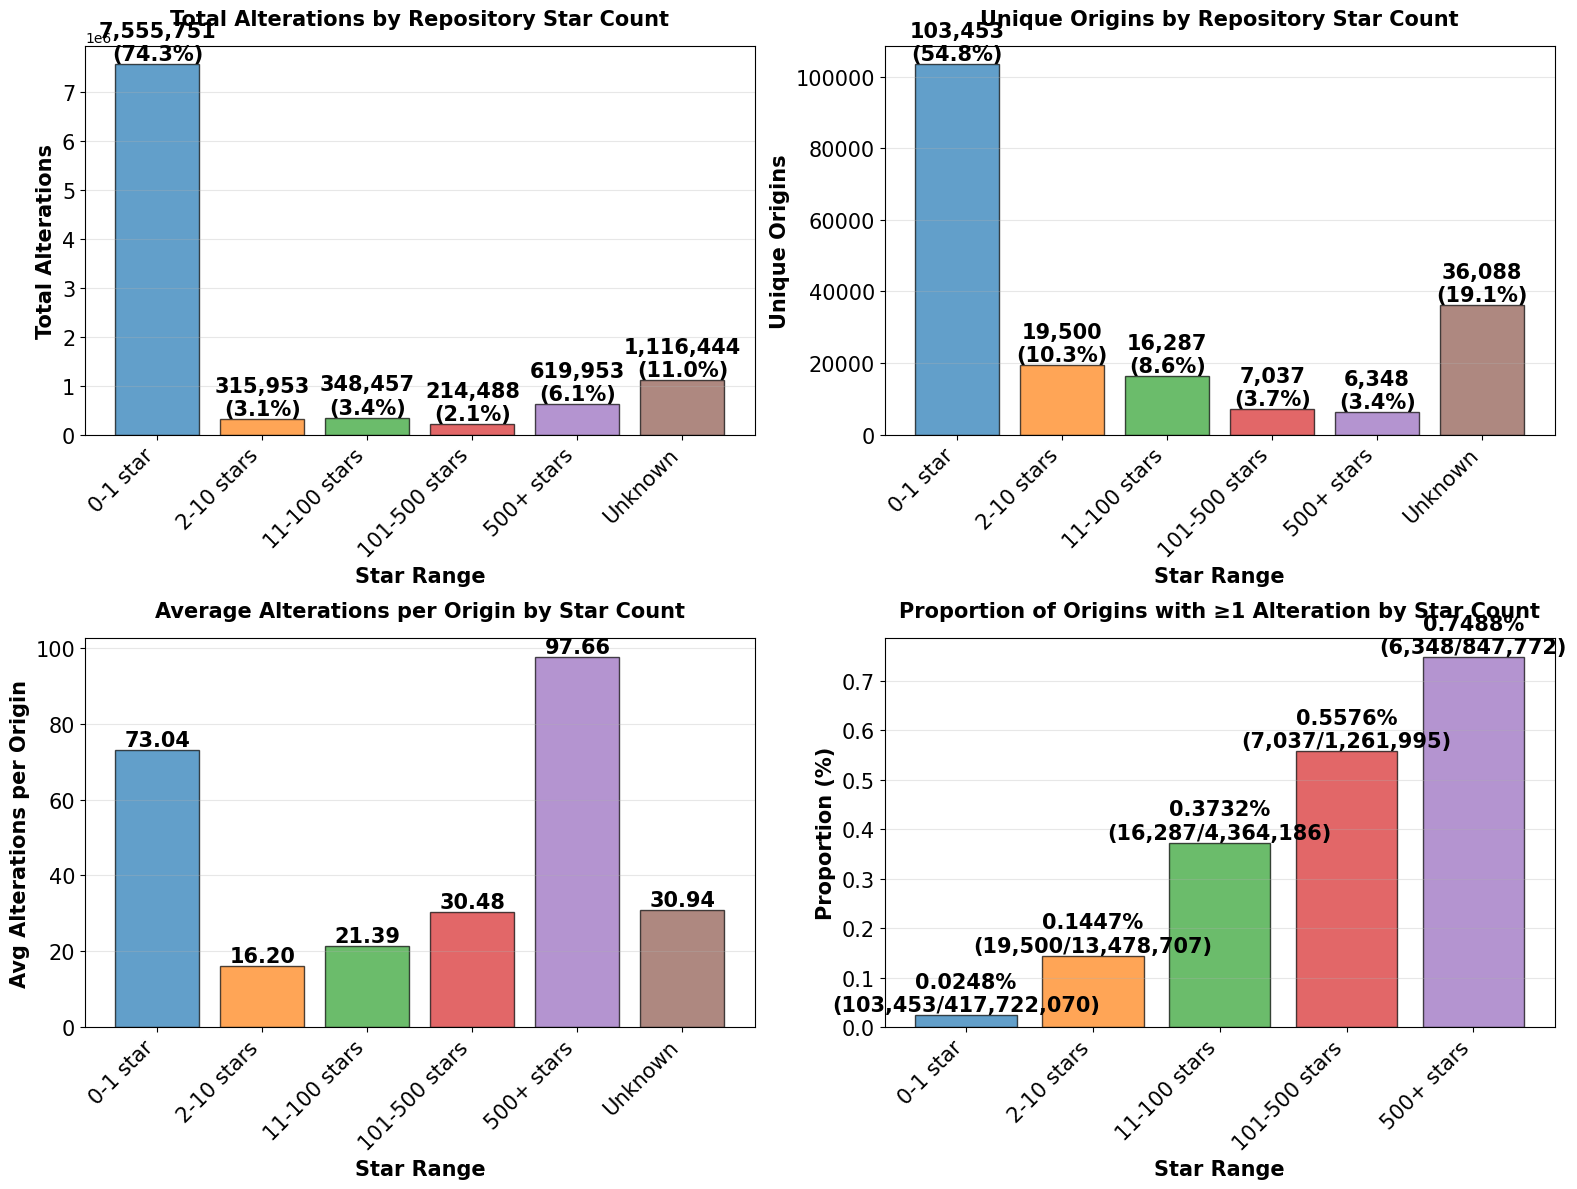


Visualization complete!
Key insights:
  - Most alterations come from: 0-1 star
  - Most origins in range: 0-1 star
  - Highest avg alterations per origin: 500+ stars (97.66)
  - Highest proportion with alterations: 500+ stars (0.7488%)


In [30]:
# Visualize star count statistics
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Define star order for plotting (exclude Unknown for some plots)
star_order = ['0-1 star', '2-10 stars', '11-100 stars', '101-500 stars', '500+ stars', 'Unknown']
x_pos = range(len(star_stats))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# ============================================================
# PLOT 1: Total Alterations by Star Range (Bar Chart)
# ============================================================
ax1 = axes[0, 0]
bars1 = ax1.bar(x_pos, star_stats['total_alterations'], color=colors[:len(star_stats)], alpha=0.7, edgecolor='black')
ax1.set_xlabel('Star Range', fontsize=FONT_SIZE-5, fontweight='bold')
ax1.set_ylabel('Total Alterations', fontsize=FONT_SIZE-5, fontweight='bold')
ax1.set_title('Total Alterations by Repository Star Count', fontsize=FONT_SIZE-5, fontweight='bold', pad=15)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(star_stats['star_range'], rotation=45, ha='right')
ax1.tick_params(axis='x', labelsize=FONT_SIZE-5)
ax1.tick_params(axis='y', labelsize=FONT_SIZE-5)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (idx, row) in enumerate(star_stats.iterrows()):
    height = row['total_alterations']
    ax1.text(i, height, f"{height:,}\n({row['pct_alterations']:.1f}%)", 
             ha='center', va='bottom', fontsize=FONT_SIZE-5, fontweight='bold')

# ============================================================
# PLOT 2: Unique Origins by Star Range (Bar Chart)
# ============================================================
ax2 = axes[0, 1]
bars2 = ax2.bar(x_pos, star_stats['unique_origins'], color=colors[:len(star_stats)], alpha=0.7, edgecolor='black')
ax2.set_xlabel('Star Range', fontsize=FONT_SIZE-5, fontweight='bold')
ax2.set_ylabel('Unique Origins', fontsize=FONT_SIZE-5, fontweight='bold')
ax2.set_title('Unique Origins by Repository Star Count', fontsize=FONT_SIZE-5, fontweight='bold', pad=15)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(star_stats['star_range'], rotation=45, ha='right')
ax2.tick_params(axis='x', labelsize=FONT_SIZE-5)
ax2.tick_params(axis='y', labelsize=FONT_SIZE-5)
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (idx, row) in enumerate(star_stats.iterrows()):
    height = row['unique_origins']
    ax2.text(i, height, f"{height:,}\n({row['pct_origins']:.1f}%)", 
             ha='center', va='bottom', fontsize=FONT_SIZE-5, fontweight='bold')

# ============================================================
# PLOT 3: Average Alterations per Origin (Bar Chart)
# ============================================================
ax3 = axes[1, 0]
star_stats['avg_per_origin'] = star_stats['total_alterations'] / star_stats['unique_origins']
bars3 = ax3.bar(x_pos, star_stats['avg_per_origin'], color=colors[:len(star_stats)], alpha=0.7, edgecolor='black')
ax3.set_xlabel('Star Range', fontsize=FONT_SIZE-5, fontweight='bold')
ax3.set_ylabel('Avg Alterations per Origin', fontsize=FONT_SIZE-5, fontweight='bold')
ax3.set_title('Average Alterations per Origin by Star Count', fontsize=FONT_SIZE-5, fontweight='bold', pad=15)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(star_stats['star_range'], rotation=45, ha='right')
ax3.tick_params(axis='x', labelsize=FONT_SIZE-5)
ax3.tick_params(axis='y', labelsize=FONT_SIZE-5)
ax3.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (idx, row) in enumerate(star_stats.iterrows()):
    height = row['avg_per_origin']
    ax3.text(i, height, f"{height:.2f}", 
             ha='center', va='bottom', fontsize=FONT_SIZE-5, fontweight='bold')

# ============================================================
# PLOT 4: Proportion of Origins with Alterations
# ============================================================
ax4 = axes[1, 1]
x_pos_prop = range(len(proportion_analysis))
bars4 = ax4.bar(x_pos_prop, proportion_analysis['proportion_with_alterations'], color=colors[:len(proportion_analysis)], alpha=0.7, edgecolor='black')
ax4.set_xlabel('Star Range', fontsize=FONT_SIZE-5, fontweight='bold')
ax4.set_ylabel('Proportion (%)', fontsize=FONT_SIZE-5, fontweight='bold')
ax4.set_title('Proportion of Origins with ≥1 Alteration by Star Count', fontsize=FONT_SIZE-5, fontweight='bold', pad=15)
ax4.set_xticks(x_pos_prop)
ax4.set_xticklabels(proportion_analysis['star_range'], rotation=45, ha='right')
ax4.tick_params(axis='x', labelsize=FONT_SIZE-5)
ax4.tick_params(axis='y', labelsize=FONT_SIZE-5)
ax4.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (idx, row) in enumerate(proportion_analysis.iterrows()):
    height = row['proportion_with_alterations']
    ax4.text(i, height, f"{height:.4f}%\n({row['origins_with_alterations']:,}/{row['total_origins']:,})", 
             ha='center', va='bottom', fontsize=FONT_SIZE-5, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nVisualization complete!")
print(f"Key insights:")
print(f"  - Most alterations come from: {star_stats.loc[star_stats['total_alterations'].idxmax(), 'star_range']}")
print(f"  - Most origins in range: {star_stats.loc[star_stats['unique_origins'].idxmax(), 'star_range']}")
print(f"  - Highest avg alterations per origin: {star_stats.loc[star_stats['avg_per_origin'].idxmax(), 'star_range']} ({star_stats['avg_per_origin'].max():.2f})")
print(f"  - Highest proportion with alterations: {proportion_analysis.loc[proportion_analysis['proportion_with_alterations'].idxmax(), 'star_range']} ({proportion_analysis['proportion_with_alterations'].max():.4f}%)")

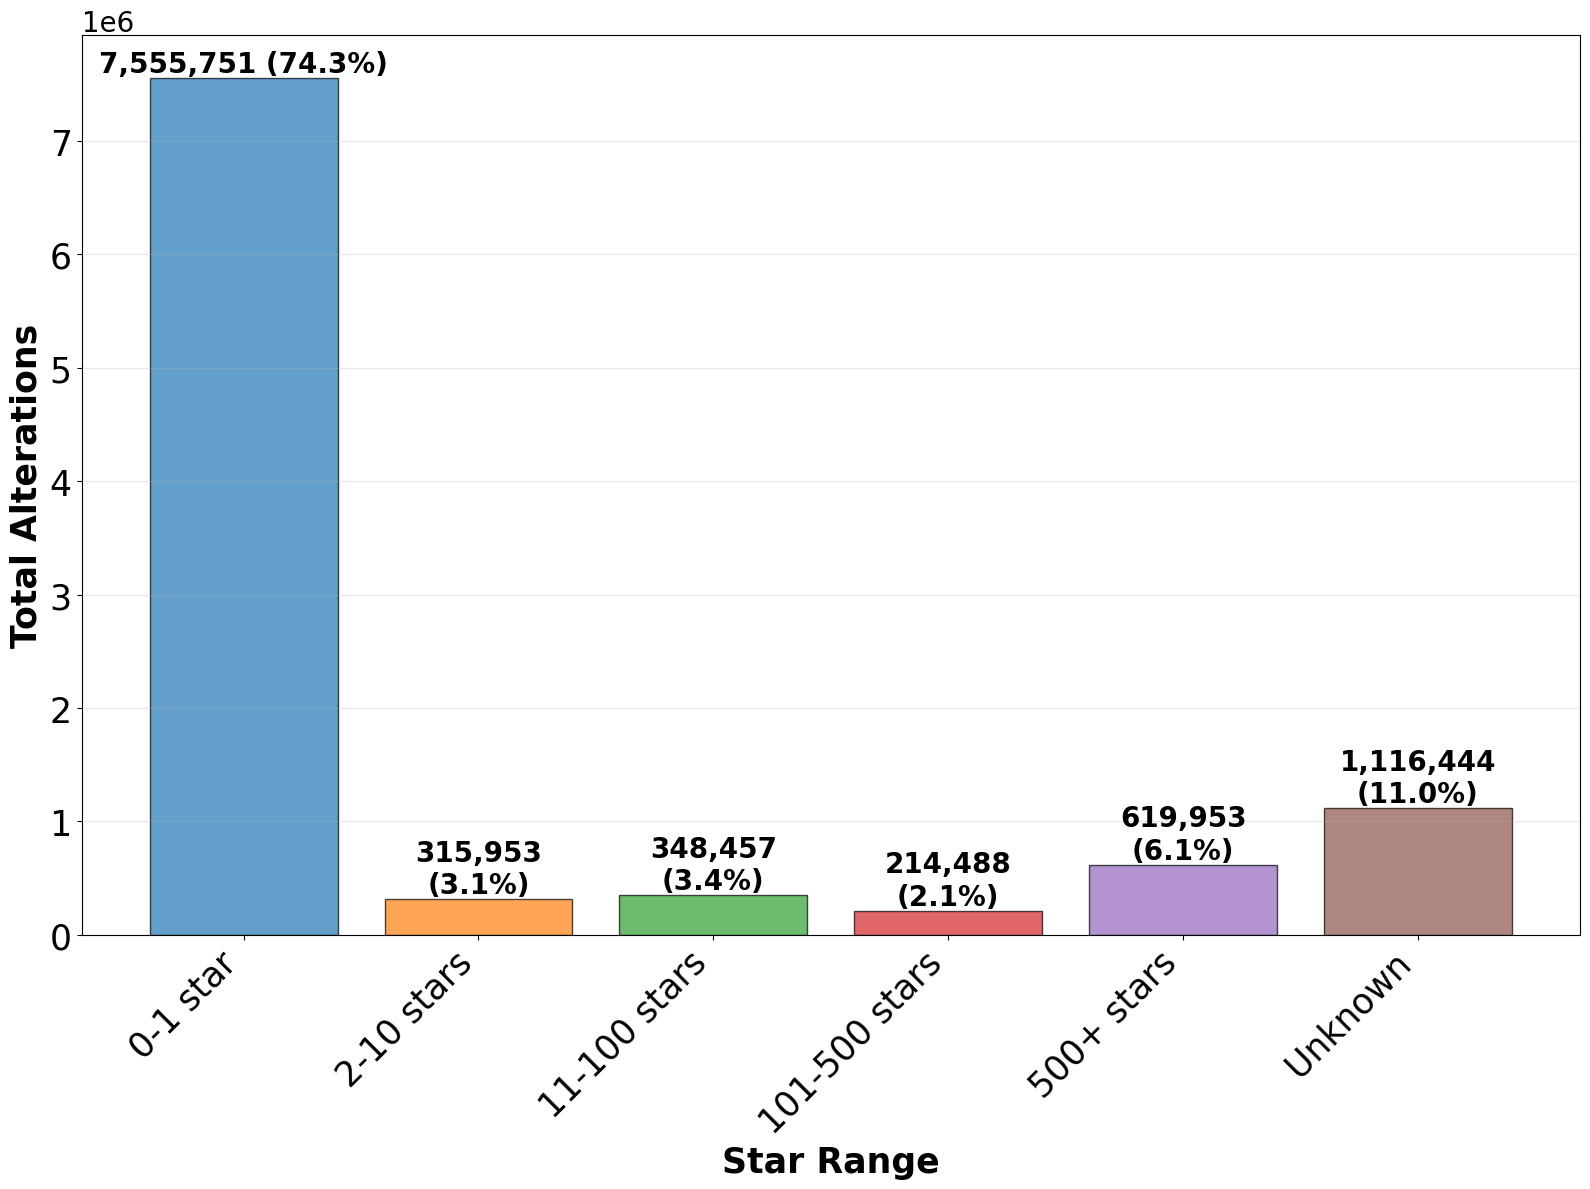

In [31]:
fig, ax = plt.subplots(figsize=(16, 12))

# Define star order for plotting (exclude Unknown for some plots)
star_order = ['0-1 star', '2-10 stars', '11-100 stars', '101-500 stars', '500+ stars', 'Unknown']
x_pos = range(len(star_stats))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# ============================================================
# PLOT 1: Total Alterations by Star Range (Bar Chart)
# ============================================================
bars1 = ax.bar(x_pos, star_stats['total_alterations'], color=colors[:len(star_stats)], alpha=0.7, edgecolor='black')
ax.set_xlabel('Star Range', fontsize=FONT_SIZE+5, fontweight='bold')
ax.set_ylabel('Total Alterations', fontsize=FONT_SIZE+5, fontweight='bold')
# ax.set_title('Total Alterations by Repository Star Count', fontsize=FONT_SIZE, fontweight='bold', pad=15)
ax.set_xticks(x_pos)
ax.set_xticklabels(star_stats['star_range'], rotation=45, ha='right')
ax.tick_params(axis='x', labelsize=FONT_SIZE+5)
ax.tick_params(axis='y', labelsize=FONT_SIZE+5)
ax.grid(axis='y', alpha=0.3)

ax.yaxis.get_offset_text().set_fontsize(FONT_SIZE)

# Add value labels on bars
for i, (idx, row) in enumerate(star_stats.iterrows()):
    height = row['total_alterations']
    if i == 0:
        ax.text(i, height, f"{height:,} ({row['pct_alterations']:.1f}%)", 
            ha='center', va='bottom', fontsize=FONT_SIZE, fontweight='bold')
    else:
        ax.text(i, height, f"{height:,}\n({row['pct_alterations']:.1f}%)", 
            ha='center', va='bottom', fontsize=FONT_SIZE, fontweight='bold')

plt.tight_layout()
plt.savefig("popularity_star_count.pdf", format="pdf")
plt.show()

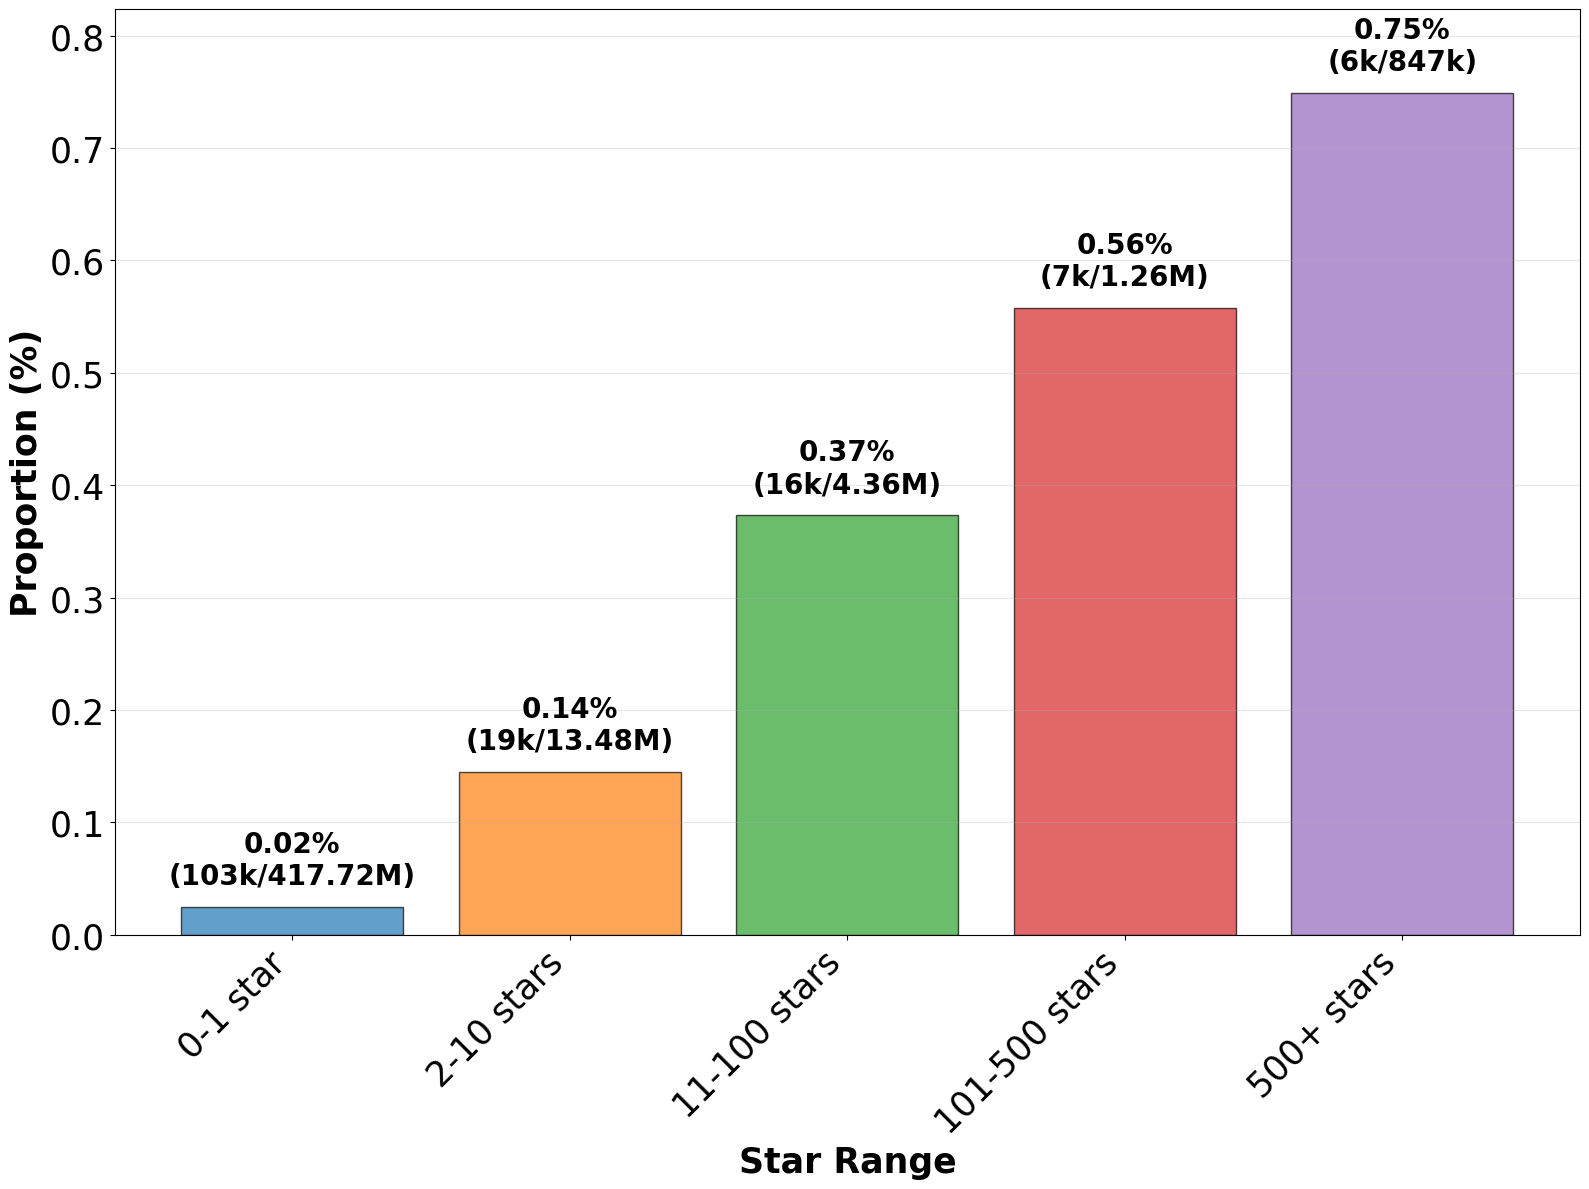

In [57]:
fig, ax4 = plt.subplots(figsize=(16, 12))

# Define star order for plotting (exclude Unknown for some plots)
star_order = ['0-1 star', '2-10 stars', '11-100 stars', '101-500 stars', '500+ stars', 'Unknown']
x_pos = range(len(star_stats))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

x_pos_prop = range(len(proportion_analysis))
bars4 = ax4.bar(x_pos_prop, proportion_analysis['proportion_with_alterations'], color=colors[:len(proportion_analysis)], alpha=0.7, edgecolor='black')
ax4.set_xlabel('Star Range', fontsize=FONT_SIZE+5, fontweight='bold')
ax4.set_ylabel('Proportion (%)', fontsize=FONT_SIZE+5, fontweight='bold')
# ax4.set_title('Proportion of Origins with ≥1 Alteration by Star Count', fontsize=FONT_SIZE, fontweight='bold', pad=15)
ax4.set_xticks(x_pos_prop)
ax4.set_xticklabels(proportion_analysis['star_range'], rotation=45, ha='right')
ax4.tick_params(axis='x', labelsize=FONT_SIZE+5)
ax4.tick_params(axis='y', labelsize=FONT_SIZE+5)
ax4.grid(axis='y', alpha=0.3)

ax4.yaxis.get_offset_text().set_fontsize(FONT_SIZE)

# Add extra top margin so labels remain visible even for the tallest bar
max_height = proportion_analysis['proportion_with_alterations'].max()
label_offset = max(0.02 * max_height, 0)
ax4.set_ylim(0, max_height + label_offset * 5)

def compact_count(n):
    n = int(n)
    if n >= 1_000_000_000:
        value = n / 1_000_000_000
        return f"{value:.2f}".rstrip('0').rstrip('.') + "B"
    if n >= 1_000_000:
        value = n / 1_000_000
        return f"{value:.2f}".rstrip('0').rstrip('.') + "M"
    if n >= 1_000:
        return f"{n // 1_000}k"
    return str(n)

# Add value labels on bars
for i, (idx, row) in enumerate(proportion_analysis.iterrows()):
    height = row['proportion_with_alterations']
    num = compact_count(row['origins_with_alterations'])
    den = compact_count(row['total_origins'])
    ax4.text(i, height + label_offset, f"{height:.2f}%\n({num}/{den})", 
             ha='center', va='bottom', fontsize=FONT_SIZE, fontweight='bold')

plt.tight_layout()
plt.savefig("popularity_proportion.pdf", format="pdf")
plt.show()

# Nix

In [15]:
shared_origins = pd.read_csv("../correlation-results/step1_shared_origins.csv")
shared_origins = shared_origins[['origin_url', 'attr_path', 'pname']].drop_duplicates()
print(f"Amount of Nix package referencing an origin that altered at least one tag: {len(shared_origins):_}")

Amount of Nix package referencing an origin that altered at least one tag: 2_407


In [16]:
shared_tags = pd.read_csv("../correlation-results/step2_altered_tag_matches.csv")
unique_tags = shared_tags[['attr_path', 'pname', 'origin_url', 'rev']].drop_duplicates()
print(f"Amount of tags referenced in Nix packages that were once altered: {len(unique_tags):_}")

Amount of tags referenced in Nix packages that were once altered: 32


In [24]:
hashes = pd.read_csv("../correlation-results/step3_hash_check_results.csv")
unique_match = hashes[hashes['hash_match']==False][['attr_path', 'forge_type', 'stored_hash', 'fetched_hash']].drop_duplicates()
print(f"Amount of Nix package that are currently storing the previous hash version of a tag: {len(unique_match):_}")

Amount of Nix package that are currently storing the previous hash version of a tag: 3


In [12]:
df[(df['origin_url']=="https://git.dthompson.us/haunt.git") & (df['tag_name'].str.contains("0.3.0"))]

,origin_url,tag_name,type,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,category,delta,platform,stars,creation_type,creation_rev,creation_rev_ts,creation_root_dir,creation_snapshot,creation_snap_ts,creation_delta,deadtime,status
4875966,https://git.dthompson.us/haunt.git,refs/tags/v0.3.0,annotated,swh:1:snp:19638c9877c6766a4c5203653437346fe5cc2ac0,1,2023-06-22 16:59:26,swh:1:rev:d7cac9e175082829ebfd31185bc3811575f2deb5,2023-03-21 17:10:39,swh:1:dir:e079f8990206762e10abf4bc72f6a4edf360c86a,swh:1:snp:dd7e7f1d145459c6f47916cb7f6ee0b2d9eb82e6,5,2023-12-15 04:21:17,NaN,NaT,NaN,2023-10-19 21:46:08,2023,NaN,Deletion,119,Other,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN


In [8]:
df[(df['origin_url']=="https://github.com/AdaCore/e3-testsuite") & (df['tag_name'].str.contains("27.2"))]

,origin_url,tag_name,type,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,category,delta,platform,stars,creation_type,creation_rev,creation_rev_ts,creation_root_dir,creation_snapshot,creation_snap_ts,creation_delta,deadtime,status
6386655,https://github.com/AdaCore/e3-testsuite,refs/tags/v27.2,lightweight,swh:1:snp:23604b488b31f7da30b22192216f23e210dde682,2,2025-06-23 18:52:03,swh:1:rev:3296441b71b6ccb5a290a1deb1367785783e8032,2025-06-17 14:19:36,swh:1:dir:d683491057df31b2f74f3713e914a3f913b2573c,swh:1:snp:79fac011d69f6d5554eb5a07804ddba654ff155a,3,2025-07-05 01:56:15,NaN,NaT,NaN,2025-06-23 18:52:03,2025,NaN,Deletion,0,GitHub,6.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN


In [9]:
df[(df['origin_url']=="https://github.com/activecm/rita") & (df['tag_name'].str.contains("4.8.1"))]

,origin_url,tag_name,type,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,category,delta,platform,stars,creation_type,creation_rev,creation_rev_ts,creation_root_dir,creation_snapshot,creation_snap_ts,creation_delta,deadtime,status
173846,https://github.com/activecm/rita,refs/tags/v4.8.1,lightweight,swh:1:snp:d73403094f9fe71651bd72c282886030e2edebf4,25,2023-12-15 18:50:20,swh:1:rev:a7f1e1874aa95e0c367948d6ac8430a76f225b4c,2023-12-13 19:55:19,swh:1:dir:e4402c21591f5c8c8564ac70a2da32528941b628,swh:1:snp:26c8ad8119e5a381369018840b664fadd44b05fd,30,2024-07-12 02:28:59,NaN,NaT,NaN,2024-04-05 18:19:25,2024,NaN,Deletion,111,GitHub,1881.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN


In [10]:
df[(df['origin_url']=="https://github.com/mahlonsmith/shelldap") & (df['tag_name'].str.contains("1.5.1"))]

,origin_url,tag_name,type,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,category,delta,platform,stars,creation_type,creation_rev,creation_rev_ts,creation_root_dir,creation_snapshot,creation_snap_ts,creation_delta,deadtime,status
2929054,https://github.com/mahlonsmith/shelldap,refs/tags/v1.5.1,lightweight,swh:1:snp:b476a46c2e1e4a8989ad68ae92501d97f1dd520a,0,2020-07-15 19:07:33,swh:1:rev:54885085b8ec0b8063f4144bfa80ba4b72698f39,2019-10-13 17:52:25,swh:1:dir:1e54d7f2a7d8d838039bb673d57291d04c414834,swh:1:snp:eefd1c6e61435a3390c868c28ac4daa82b7c14c3,4,2025-07-09 19:17:13,NaN,NaT,NaN,2025-01-22 07:31:26,2025,NaN,Deletion,1651,GitHub,23.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN


In [13]:
df[(df['origin_url']=="https://github.com/PerryWerneck/libv3270") & (df['tag_name'].str.contains("5.5.0"))]

,origin_url,tag_name,type,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,category,delta,platform,stars,creation_type,creation_rev,creation_rev_ts,creation_root_dir,creation_snapshot,creation_snap_ts,creation_delta,deadtime,status
9897115,https://github.com/PerryWerneck/libv3270,refs/tags/5.5.0,lightweight,swh:1:snp:408f44ad8ebabc3bb2af9de19828532ab8af10c9,29,2024-12-14 15:07:21,swh:1:rev:d4465dfe697de65be69e507928d2907231a66d0e,2024-12-11 08:58:10,swh:1:dir:e56514aa0a4043884994fb69237da68c7d0bc508,swh:1:snp:ba8ca04a1f63ede831117994f84f244121564323,31,2025-05-01 06:44:24,swh:1:rev:8db00b1930031c8e04f7cdef04809d28eac18c96,2025-04-16 02:53:54,swh:1:dir:3a34a1049b9f658fb36d1f145058771933fb6457,2025-02-18 14:17:09,2025,2025.0,Move,65,GitHub,5.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN
9897116,https://github.com/PerryWerneck/libv3270,refs/tags/5.5.0,lightweight,swh:1:snp:ba8ca04a1f63ede831117994f84f244121564323,31,2025-05-01 06:44:24,swh:1:rev:8db00b1930031c8e04f7cdef04809d28eac18c96,2025-04-16 02:53:54,swh:1:dir:3a34a1049b9f658fb36d1f145058771933fb6457,swh:1:snp:eb104de0372cd03469106e7f2c8663f8724a3abc,35,2025-09-03 12:25:55,swh:1:rev:9bf0f51a9022fc08c6ba3d1cddfc314620f99d41,2025-08-15 10:31:39,swh:1:dir:179385a1a2610c78d24f8a7591de821b62a2508c,2025-08-13 16:42:05,2025,2025.0,Move,104,GitHub,5.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN


In [14]:
df[(df['origin_url']=="https://github.com/leeping/geomeTRIC") & (df['tag_name'].str.contains("1.1"))]

,origin_url,tag_name,type,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,category,delta,platform,stars,creation_type,creation_rev,creation_rev_ts,creation_root_dir,creation_snapshot,creation_snap_ts,creation_delta,deadtime,status
11879437,https://github.com/leeping/geomeTRIC,refs/tags/1.1,lightweight,swh:1:snp:7c9abf1b09c28e6ab4d9b8b4d6609d47ee144a0a,81,2025-01-29 02:49:55,swh:1:rev:53cdef69e3df7eb15ccb04716a5c31c635e61f30,2025-01-24 21:21:57,swh:1:dir:8c9b6772a251d42c6e005259958ac92ae15813b9,swh:1:snp:88f899c245e4b0b05a3fb71c924f75673b823d86,82,2025-02-03 04:02:36,swh:1:rev:73912c91708304c2413548f325d0753d70eb3ae5,2025-01-30 19:56:03,swh:1:dir:d4b946b1ad9a55454910d6813a6340580425a133,2025-01-29 02:49:55,2025,2025.0,Move,0,GitHub,80.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN


In [15]:
df[(df['origin_url']=="https://github.com/xiaoyeli/superlu") & (df['tag_name'].str.contains("7.0.1"))]

,origin_url,tag_name,type,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,category,delta,platform,stars,creation_type,creation_rev,creation_rev_ts,creation_root_dir,creation_snapshot,creation_snap_ts,creation_delta,deadtime,status
394253,https://github.com/xiaoyeli/superlu,refs/tags/v7.0.1,lightweight,swh:1:snp:8858c4591ec090b4d713167bac277f09959a92e5,48,2025-04-28 14:53:33,swh:1:rev:4ef39075e029927e8c959b22c8e7052dcb40c995,2025-04-20 17:43:00,swh:1:dir:1a47626e60bf2c63219aa4de9c0173ec8f0f72ce,swh:1:snp:85a93cd0a374875828d8d50e58336e07e91c06b3,49,2025-05-09 19:06:20,swh:1:rev:83a3c82b9e44c966ca2bc26991ffdb2bf63e1e2b,2025-05-07 23:47:22,swh:1:dir:8db87f1f37c0ddf07f0431d5556286e86ad14c22,2025-04-28 14:53:33,2025,2025.0,Move,0,GitHub,164.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN
